In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

processed_dir = Path("../data/processed")

gene_expression = pd.read_csv(
    processed_dir / "GSE75037_gene_expression.tsv.gz",
    sep="\t",
    index_col=0
)

metadata = pd.read_csv(
    processed_dir / "GSE75037_metadata.tsv",
    sep="\t"
)

print("Gene-expression shape:", gene_expression.shape)
print("Metadata shape:", metadata.shape)

Gene-expression shape: (25440, 166)
Metadata shape: (166, 5)


In [2]:
print(metadata["status_from_title"].value_counts())

status_from_title
Normal    83
Tumor     83
Name: count, dtype: int64


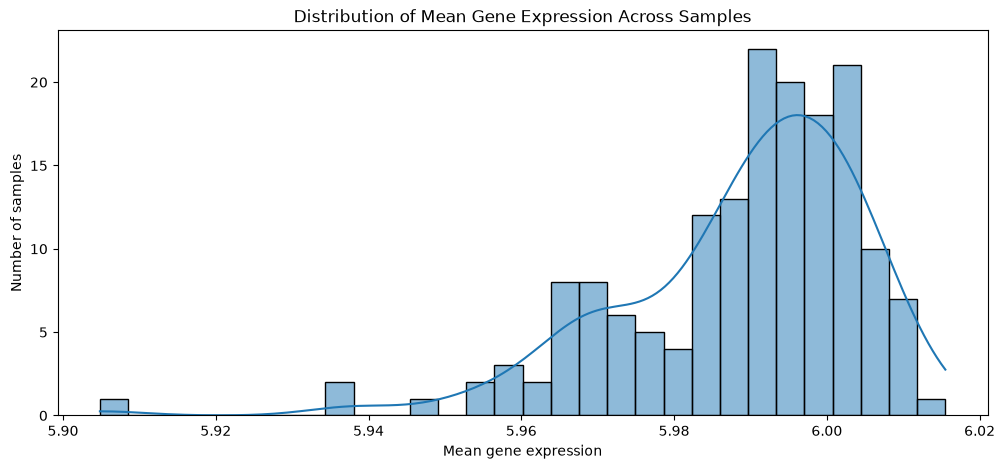

In [3]:
sample_means = gene_expression.mean(axis=0)

plt.figure(figsize=(12, 5))

sns.histplot(
    sample_means,
    bins=30,
    kde=True
)

plt.xlabel("Mean gene expression")
plt.ylabel("Number of samples")
plt.title("Distribution of Mean Gene Expression Across Samples")

plt.show()

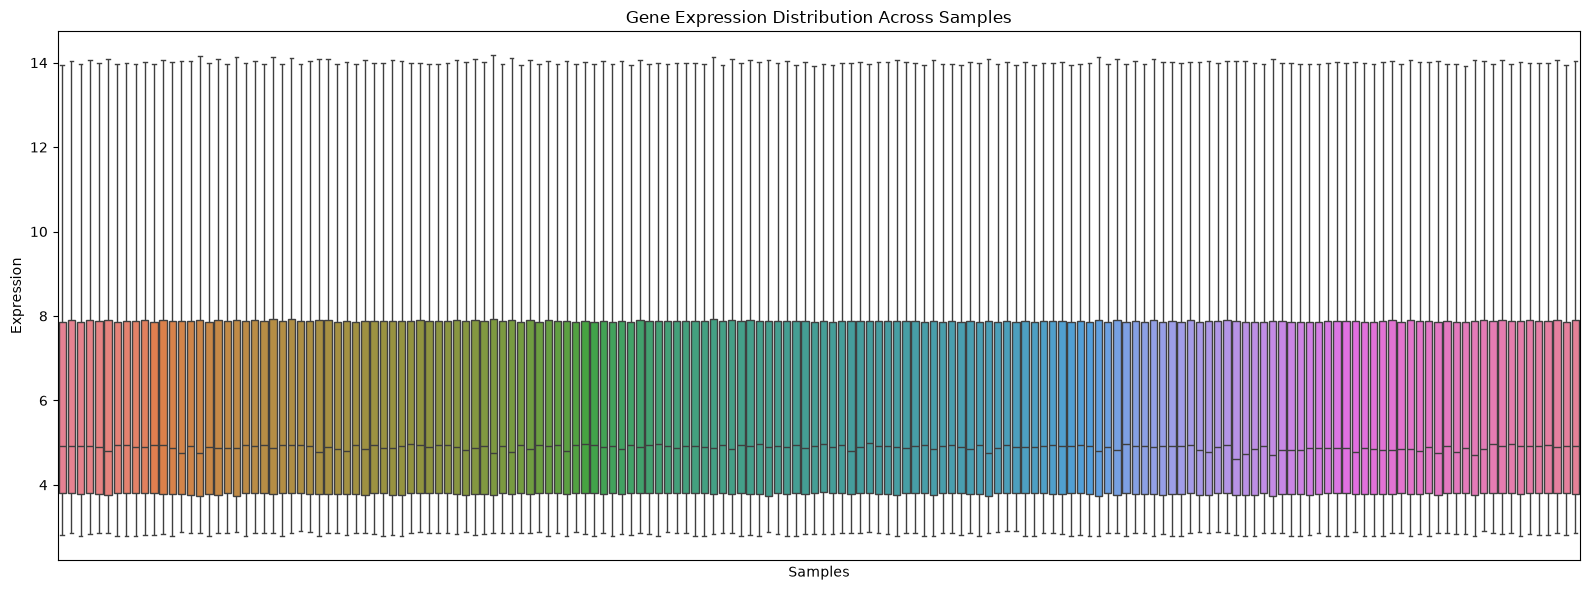

In [4]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=gene_expression,
    showfliers=False
)

plt.xlabel("Samples")
plt.ylabel("Expression")
plt.title("Gene Expression Distribution Across Samples")

plt.xticks([])
plt.tight_layout()
plt.show()

In [6]:
showfliers=False


In [7]:
# Keep metadata in the same order as the expression matrix
metadata_ordered = (
    metadata
    .set_index("sample_id")
    .loc[gene_expression.columns]
)

print(metadata_ordered["status_from_title"].value_counts())

KeyError: "None of [Index(['GSM1941120', 'GSM1941121', 'GSM1941122', 'GSM1941123', 'GSM1941124',\n       'GSM1941125', 'GSM1941126', 'GSM1941127', 'GSM1941128', 'GSM1941129',\n       ...\n       'GSM1941276', 'GSM1941277', 'GSM1941278', 'GSM1941279', 'GSM1941280',\n       'GSM1941281', 'GSM1941282', 'GSM1941283', 'GSM1941284', 'GSM1941285'],\n      dtype='str', length=166)] are in the [index]"

In [8]:
# Clean sample IDs in both datasets
gene_expression.columns = (
    gene_expression.columns
    .astype(str)
    .str.strip()
    .str.strip('"')
)

metadata["sample_id"] = (
    metadata["sample_id"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)

# Check overlap
expression_samples = set(gene_expression.columns)
metadata_samples = set(metadata["sample_id"])

print("Expression samples:", len(expression_samples))
print("Metadata samples:", len(metadata_samples))
print("Common samples:", len(expression_samples & metadata_samples))

print(
    "Missing from metadata:",
    len(expression_samples - metadata_samples)
)

print(
    "Missing from expression:",
    len(metadata_samples - expression_samples)
)

Expression samples: 166
Metadata samples: 166
Common samples: 166
Missing from metadata: 0
Missing from expression: 0


In [9]:
# Align metadata to expression matrix order
metadata_ordered = (
    metadata
    .set_index("sample_id")
    .reindex(gene_expression.columns)
)

print("Metadata aligned:", metadata_ordered.shape)

print("\nSample groups:")
print(metadata_ordered["status_from_title"].value_counts())

Metadata aligned: (166, 4)

Sample groups:
status_from_title
Normal    83
Tumor     83
Name: count, dtype: int64


In [10]:
sample_summary = pd.DataFrame({
    "sample_id": gene_expression.columns,
    "mean_expression": gene_expression.mean(axis=0).values,
    "status": metadata_ordered["status_from_title"].values
})

display(sample_summary.head())

,sample_id,mean_expression,status
0,GSM1941120,5.994439,Normal
1,GSM1941121,6.001166,Tumor
2,GSM1941122,5.996853,Normal
3,GSM1941123,6.003209,Tumor
4,GSM1941124,5.994064,Normal


In [11]:
# Select the 2,000 most variable genes
gene_variances = gene_expression.var(axis=1)

top_variable_genes = (
    gene_variances
    .sort_values(ascending=False)
    .head(2000)
    .index
)

pca_expression = gene_expression.loc[top_variable_genes]

print("PCA input shape:", pca_expression.shape)

PCA input shape: (2000, 166)


In [12]:
from sklearn.decomposition import PCA

# Samples × genes
X = pca_expression.T

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

print("PCA shape:", X_pca.shape)

print(
    "PC1 variance explained:",
    round(pca.explained_variance_ratio_[0] * 100, 2),
    "%"
)

print(
    "PC2 variance explained:",
    round(pca.explained_variance_ratio_[1] * 100, 2),
    "%"
)

PCA shape: (166, 2)
PC1 variance explained: 41.46 %
PC2 variance explained: 6.32 %


In [13]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"],
    index=gene_expression.columns
)

pca_df = pca_df.join(
    metadata_ordered[["status_from_title"]]
)

pca_df = pca_df.rename(
    columns={"status_from_title": "Status"}
)

display(pca_df.head())

,PC1,PC2,Status
GSM1941120,54.906060,-11.176720,Normal
GSM1941121,-55.396519,-5.553113,Tumor
GSM1941122,62.489451,-12.682767,Normal
GSM1941123,-24.145703,22.179000,Tumor
GSM1941124,56.300217,-10.757602,Normal


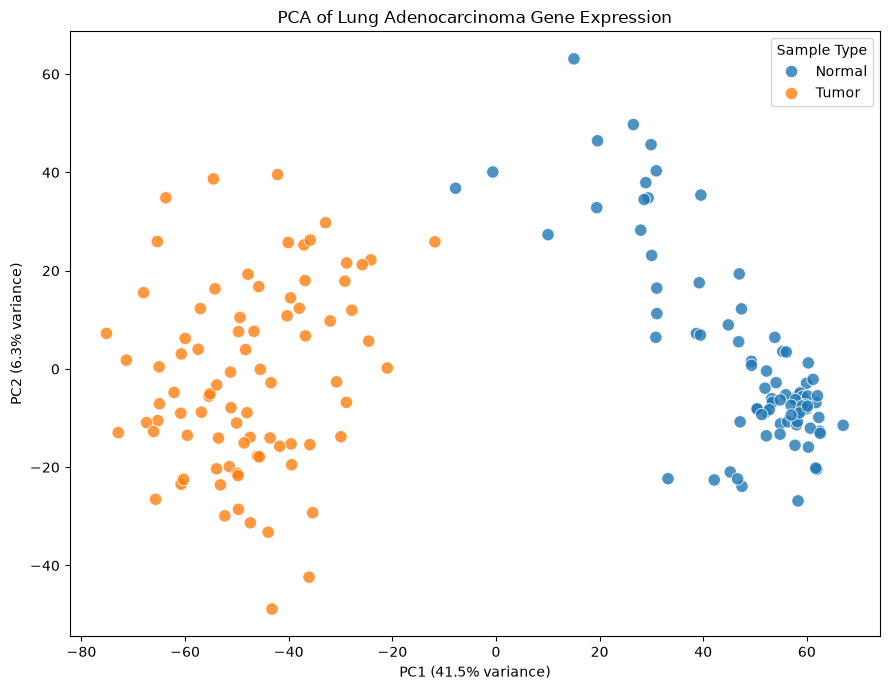

In [14]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Status",
    s=80,
    alpha=0.8
)

plt.title("PCA of Lung Adenocarcinoma Gene Expression")
plt.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)"
)
plt.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)"
)

plt.legend(title="Sample Type")
plt.tight_layout()
plt.show()

In [15]:
print(
    f"PC1 explains {pca.explained_variance_ratio_[0] * 100:.2f}% of variance"
)

print(
    f"PC2 explains {pca.explained_variance_ratio_[1] * 100:.2f}% of variance"
)

print(
    f"PC1 + PC2 explain "
    f"{pca.explained_variance_ratio_[:2].sum() * 100:.2f}% of variance"
)

PC1 explains 41.46% of variance
PC2 explains 6.32% of variance
PC1 + PC2 explain 47.77% of variance


In [16]:
# Create pair/sample lookup
pair_info = metadata_ordered[
    ["pair_id", "status_from_title"]
].copy()

pair_info["sample_id"] = pair_info.index

# Separate tumor and normal samples
tumor_samples = pair_info.loc[
    pair_info["status_from_title"] == "Tumor"
].set_index("pair_id")["sample_id"]

normal_samples = pair_info.loc[
    pair_info["status_from_title"] == "Normal"
].set_index("pair_id")["sample_id"]

# Keep only pairs present in both groups
common_pairs = tumor_samples.index.intersection(
    normal_samples.index
)

print("Complete paired patients:", len(common_pairs))

# Expression matrices: genes × patients
tumor_expr = gene_expression[
    tumor_samples.loc[common_pairs].values
].copy()

normal_expr = gene_expression[
    normal_samples.loc[common_pairs].values
].copy()

# Give both matrices identical patient-based column names
tumor_expr.columns = common_pairs
normal_expr.columns = common_pairs

print("Tumor matrix:", tumor_expr.shape)
print("Normal matrix:", normal_expr.shape)

Complete paired patients: 83
Tumor matrix: (25440, 83)
Normal matrix: (25440, 83)


In [17]:
# Tumor - Normal for every gene in every patient
paired_difference = tumor_expr - normal_expr

print("Paired difference matrix:", paired_difference.shape)

display(paired_difference.head())

Paired difference matrix: (25440, 83)


pair_id,05L4,05L6,05L7,05L9,05L10,05L12,05L13,05L19,05L27,05L32,...,3032,3033,3035,3036,3039,L1,L2,L9,L12,L15
Symbol,,,,,,,,,,,,,,,,,,,,,
15E1.2,0.993,-0.304,-1.107,0.059,0.549,-0.852,-0.315,-0.240,1.384,-0.211,...,-1.495,1.105,1.826,1.448,1.489,-0.274,1.003,0.071,1.162,1.682
2'-PDE,0.307,-0.628,-0.251,0.271,0.047,-0.058,-0.031,-0.264,0.743,-0.548,...,0.083,-0.014,0.103,0.000,0.277,-0.277,0.476,0.089,0.486,0.142
76P,-0.800,-0.925,1.091,-0.337,0.320,-1.712,-0.142,0.507,-0.535,1.355,...,0.144,0.638,-0.229,1.048,-1.308,-0.140,0.142,0.279,0.487,-1.371
7A5,2.120,-0.238,0.211,0.366,-0.366,2.158,-0.405,0.401,0.291,0.543,...,0.182,0.533,1.813,0.302,0.429,0.023,0.447,1.165,0.112,0.061
A1BG,-0.757,0.487,0.278,0.184,0.598,0.136,-0.255,0.166,-0.917,-0.532,...,0.062,-1.006,-1.495,-1.367,-1.732,-0.585,0.155,-0.844,0.459,0.590


In [18]:
from scipy.stats import ttest_1samp

# Test whether the mean paired difference is different from zero
test_results = ttest_1samp(
    paired_difference,
    popmean=0,
    axis=1
)

de_results = pd.DataFrame({
    "gene": paired_difference.index,
    "log2FC": paired_difference.mean(axis=1),
    "p_value": test_results.pvalue
})

display(de_results.head())

,gene,log2FC,p_value
Symbol,,,
15E1.2,15E1.2,0.308446,2.399415e-02
2'-PDE,2'-PDE,0.041771,5.255083e-01
76P,76P,0.090578,2.265534e-01
7A5,7A5,0.572398,5.703965e-08
A1BG,A1BG,-0.106831,2.057745e-01


In [19]:
def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values)
    n = len(p_values)

    order = np.argsort(p_values)
    ranked_p = p_values[order]

    adjusted = ranked_p * n / np.arange(1, n + 1)

    # Enforce monotonicity from largest rank backwards
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]

    adjusted = np.clip(adjusted, 0, 1)

    result = np.empty(n)
    result[order] = adjusted

    return result


de_results["FDR"] = benjamini_hochberg(
    de_results["p_value"]
)

de_results = de_results.sort_values(
    ["FDR", "p_value"]
)

display(de_results.head(20))

,gene,log2FC,p_value,FDR
Symbol,,,,
FABP4,FABP4,-6.025675,2.933026e-61,7.461619e-57
LOC653463,LOC653463,-6.985795,7.890562e-57,1.003680e-52
LOC401286,LOC401286,-7.605771,4.698890e-56,3.984659e-52
XLKD1,XLKD1,-4.968048,1.139635e-51,7.248078e-48
FMO2,FMO2,-3.657639,1.466642e-51,7.462273e-48
PYCR1,PYCR1,3.490590,3.806397e-51,1.613912e-47
CAV1,CAV1,-4.555735,6.470337e-51,2.351505e-47
SH3GL3,SH3GL3,-3.555735,8.248859e-51,2.623137e-47
ITLN2,ITLN2,-6.018506,1.201420e-50,3.396013e-47


In [20]:
de_results["significant"] = (
    (de_results["FDR"] < 0.05) &
    (de_results["log2FC"].abs() >= 1)
)

significant_genes = de_results[
    de_results["significant"]
].copy()

print(
    "Significant genes:",
    len(significant_genes)
)

print(
    "Upregulated:",
    (significant_genes["log2FC"] > 0).sum()
)

print(
    "Downregulated:",
    (significant_genes["log2FC"] < 0).sum()
)

Significant genes: 3762
Upregulated: 1807
Downregulated: 1955


In [21]:
# Prepare volcano plot values
de_results["neg_log10_FDR"] = -np.log10(
    de_results["FDR"].clip(lower=1e-300)
)

# Classify genes
de_results["DE_category"] = "Not significant"

de_results.loc[
    (de_results["FDR"] < 0.05) &
    (de_results["log2FC"] >= 1),
    "DE_category"
] = "Upregulated"

de_results.loc[
    (de_results["FDR"] < 0.05) &
    (de_results["log2FC"] <= -1),
    "DE_category"
] = "Downregulated"

print(de_results["DE_category"].value_counts())

DE_category
Not significant    21678
Downregulated       1955
Upregulated         1807
Name: count, dtype: int64


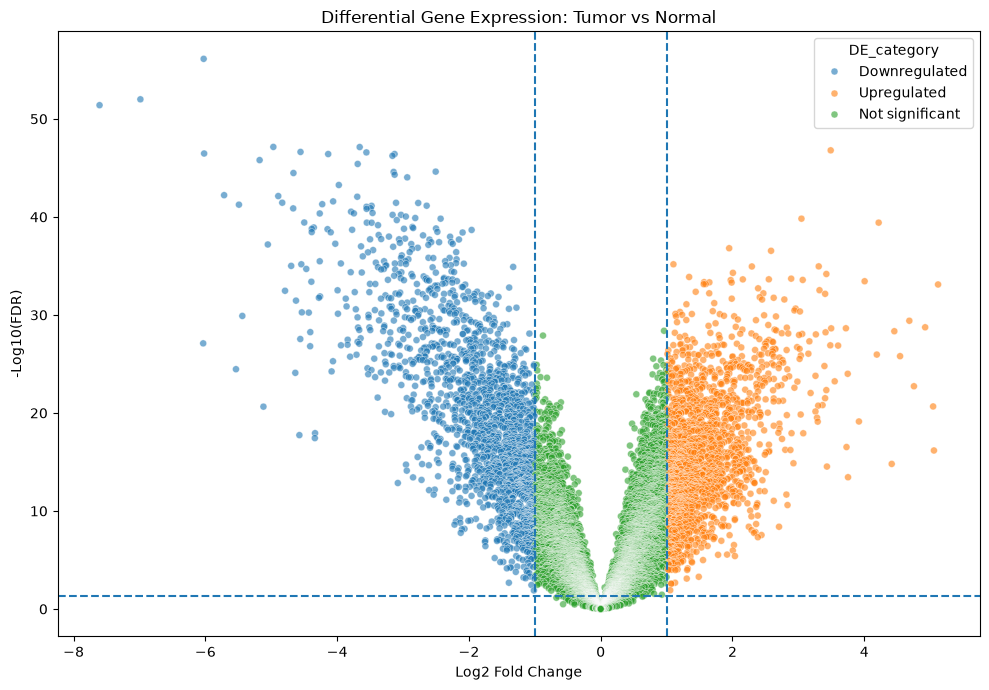

In [22]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=de_results,
    x="log2FC",
    y="neg_log10_FDR",
    hue="DE_category",
    alpha=0.6,
    s=25
)

plt.axvline(1, linestyle="--")
plt.axvline(-1, linestyle="--")
plt.axhline(-np.log10(0.05), linestyle="--")

plt.xlabel("Log2 Fold Change")
plt.ylabel("-Log10(FDR)")
plt.title("Differential Gene Expression: Tumor vs Normal")

plt.tight_layout()
plt.show()

In [23]:
# Rank by absolute effect size among significant genes
candidate_genes = (
    significant_genes
    .assign(abs_log2FC=lambda x: x["log2FC"].abs())
    .sort_values(
        ["abs_log2FC", "FDR"],
        ascending=[False, True]
    )
)

print("Top candidate genes by absolute log2FC:")

display(
    candidate_genes[
        ["gene", "log2FC", "p_value", "FDR"]
    ].head(25)
)

Top candidate genes by absolute log2FC:


,gene,log2FC,p_value,FDR
Symbol,,,,
LOC401286,LOC401286,-7.605771,4.698890e-56,3.984659e-52
LOC653463,LOC653463,-6.985795,7.890562e-57,1.003680e-52
CLDN18,CLDN18,-6.032675,1.381503e-29,7.951453e-28
FABP4,FABP4,-6.025675,2.933026e-61,7.461619e-57
ITLN2,ITLN2,-6.018506,1.201420e-50,3.396013e-47
AGER,AGER,-5.715253,4.997167e-46,6.053710e-43
SFTPA1,SFTPA1,-5.535241,9.521136e-27,3.435712e-25
CA4,CA4,-5.490265,6.416153e-45,5.628515e-42
GDDR,GDDR,-5.438819,1.463636e-32,1.262200e-30


In [24]:
top_up = (
    significant_genes[
        significant_genes["log2FC"] > 0
    ]
    .sort_values("log2FC", ascending=False)
    .head(15)
)

top_down = (
    significant_genes[
        significant_genes["log2FC"] < 0
    ]
    .sort_values("log2FC", ascending=True)
    .head(15)
)

print("Top upregulated genes:")
display(top_up[["gene", "log2FC", "FDR"]])

print("\nTop downregulated genes:")
display(top_down[["gene", "log2FC", "FDR"]])

Top upregulated genes:


,gene,log2FC,FDR
Symbol,,,
MMP11,MMP11,5.120181,7.815709e-34
XAGE1,XAGE1,5.057398,6.744560e-17
EEF1A2,EEF1A2,5.045012,2.172585e-21
GCNT3,GCNT3,4.924301,1.819665e-29
CST1,CST1,4.753855,1.881860e-23
FAM83A,FAM83A,4.684024,3.922344e-30
COL11A1,COL11A1,4.543313,1.605898e-26
ITPKA,ITPKA,4.456325,4.594473e-29
SPINK1,SPINK1,4.416627,1.581887e-15



Top downregulated genes:


,gene,log2FC,FDR
Symbol,,,
LOC401286,LOC401286,-7.605771,3.984659e-52
LOC653463,LOC653463,-6.985795,1.003680e-52
CLDN18,CLDN18,-6.032675,7.951453e-28
FABP4,FABP4,-6.025675,7.461619e-57
ITLN2,ITLN2,-6.018506,3.396013e-47
AGER,AGER,-5.715253,6.053710e-43
SFTPA1,SFTPA1,-5.535241,3.435712e-25
CA4,CA4,-5.490265,5.628515e-42
GDDR,GDDR,-5.438819,1.262200e-30


In [25]:
import gseapy as gp

print("gseapy version:", gp.__version__)

gseapy version: 1.3.1


In [28]:
up_enrichment = gp.enrichr(
    gene_list=up_genes,
    gene_sets=["GO_Biological_Process_2023"],
    organism="human",
    outdir=None
)

down_enrichment = gp.enrichr(
    gene_list=down_genes,
    gene_sets=["GO_Biological_Process_2023"],
    organism="human",
    outdir=None
)

In [29]:
print("Top pathways for upregulated genes:")

display(
    up_enrichment.results[
        [
            "Term",
            "Overlap",
            "P-value",
            "Adjusted P-value",
            "Combined Score"
        ]
    ].head(20)
)

Top pathways for upregulated genes:


,Term,Overlap,P-value,Adjusted P-value,Combined Score
0,Microtubule Cytoskeleton Organization Involved...,18/59,0.000003,0.004056,57.293900
1,Mitotic Spindle Organization (GO:0007052),22/85,0.000004,0.004056,43.694364
2,Mitotic Spindle Elongation (GO:0000022),7/10,0.000005,0.004056,289.969087
3,Mitotic Spindle Midzone Assembly (GO:0051256),7/10,0.000005,0.004056,289.969087
4,Negative Regulation Of Mitotic Metaphase/Anaph...,11/28,0.000016,0.011366,72.319095
5,Mitotic Spindle Assembly Checkpoint Signaling ...,10/26,0.000048,0.021548,62.803587
6,Mitotic Spindle Checkpoint Signaling (GO:0071174),10/26,0.000048,0.021548,62.803587
7,Spindle Assembly Checkpoint Signaling (GO:0071...,10/26,0.000048,0.021548,62.803587
8,Positive Regulation Of Cell Cycle Process (GO:...,24/118,0.000123,0.047263,23.324834
9,Regulation Of Nuclear Division (GO:0051783),8/19,0.000133,0.047263,65.605828


In [30]:
print("Top pathways for downregulated genes:")

display(
    down_enrichment.results[
        [
            "Term",
            "Overlap",
            "P-value",
            "Adjusted P-value",
            "Combined Score"
        ]
    ].head(20)
)

Top pathways for downregulated genes:


,Term,Overlap,P-value,Adjusted P-value,Combined Score
0,Inflammatory Response (GO:0006954),61/236,7.961023e-13,3.115184e-09,91.622607
1,Cellular Response To Cytokine Stimulus (GO:007...,72/308,1.512592e-12,3.115184e-09,78.533163
2,Positive Regulation Of Phagocytosis (GO:0050766),25/60,8.484752e-11,1.164956e-07,154.572494
3,Positive Regulation Of MAPK Cascade (GO:0043410),68/310,1.290005e-10,1.318015e-07,60.367175
4,Cellular Response To Type II Interferon (GO:00...,26/66,1.599922e-10,1.318015e-07,136.846705
5,Regulation Of ERK1 And ERK2 Cascade (GO:0070372),57/244,3.270674e-10,2.245318e-07,62.638232
6,Positive Regulation Of Endocytosis (GO:0045807),28/79,5.794770e-10,3.075654e-07,109.038228
7,Positive Regulation Of Response To External St...,42/155,5.973594e-10,3.075654e-07,73.996042
8,Cytokine-Mediated Signaling Pathway (GO:0019221),58/257,9.410918e-10,4.307063e-07,56.987184
9,Regulation Of Inflammatory Response (GO:0050727),55/240,1.408642e-09,5.802198e-07,56.955625


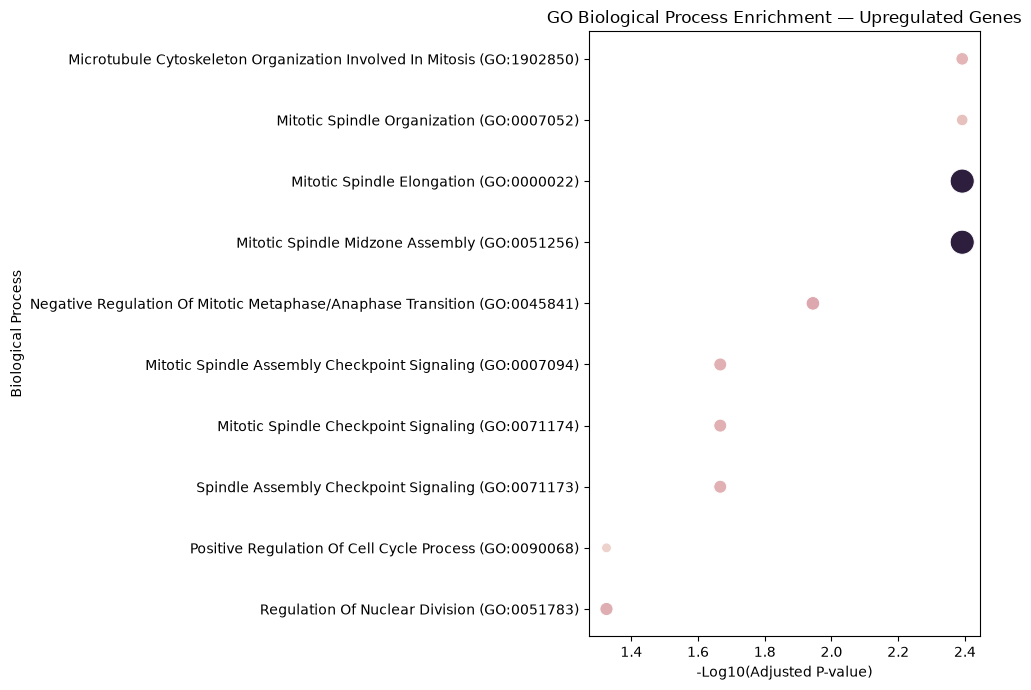

In [31]:
# Select significant upregulated pathways
up_pathways = (
    up_enrichment.results[
        up_enrichment.results["Adjusted P-value"] < 0.05
    ]
    .sort_values("Adjusted P-value")
    .head(15)
    .copy()
)

up_pathways["-log10_adjP"] = -np.log10(
    up_pathways["Adjusted P-value"]
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=up_pathways,
    x="-log10_adjP",
    y="Term",
    size="Combined Score",
    hue="Combined Score",
    sizes=(50, 300),
    legend=False
)

plt.xlabel("-Log10(Adjusted P-value)")
plt.ylabel("Biological Process")
plt.title("GO Biological Process Enrichment — Upregulated Genes")

plt.tight_layout()
plt.show()

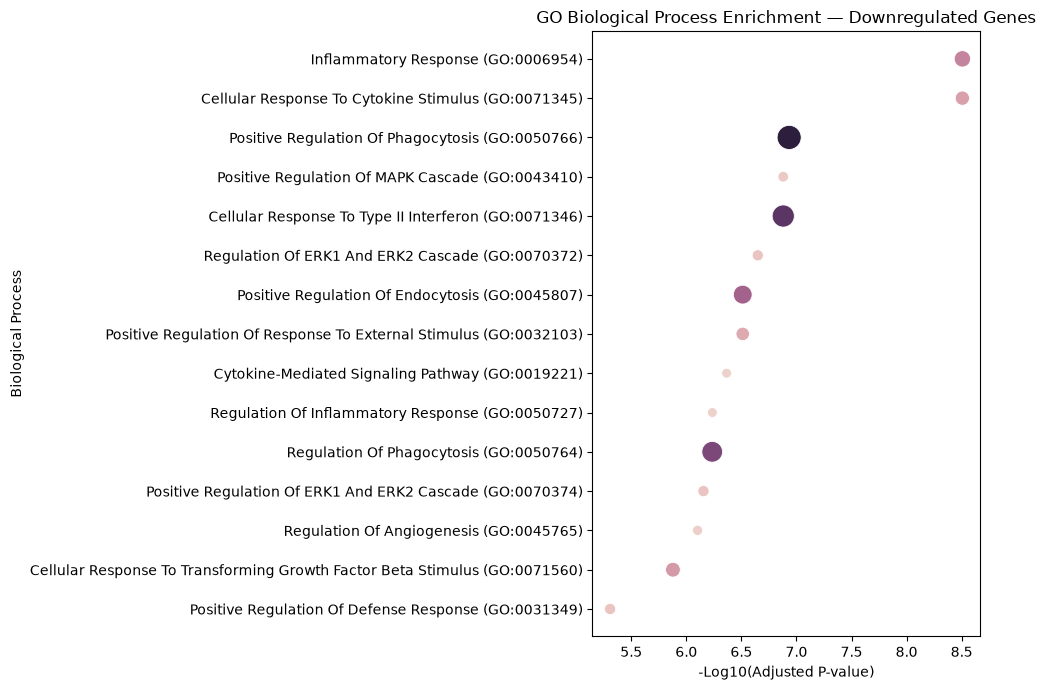

In [32]:
down_pathways = (
    down_enrichment.results[
        down_enrichment.results["Adjusted P-value"] < 0.05
    ]
    .sort_values("Adjusted P-value")
    .head(15)
    .copy()
)

down_pathways["-log10_adjP"] = -np.log10(
    down_pathways["Adjusted P-value"]
)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=down_pathways,
    x="-log10_adjP",
    y="Term",
    size="Combined Score",
    hue="Combined Score",
    sizes=(50, 300),
    legend=False
)

plt.xlabel("-Log10(Adjusted P-value)")
plt.ylabel("Biological Process")
plt.title("GO Biological Process Enrichment — Downregulated Genes")

plt.tight_layout()
plt.show()

In [33]:
from pathlib import Path

results_tables = Path("../results/tables")
results_tables.mkdir(parents=True, exist_ok=True)

up_enrichment.results.to_csv(
    results_tables / "GO_upregulated_enrichment.csv",
    index=False
)

down_enrichment.results.to_csv(
    results_tables / "GO_downregulated_enrichment.csv",
    index=False
)

print("Enrichment tables saved.")

Enrichment tables saved.


In [34]:
results_figures = Path("../results/figures")
results_figures.mkdir(parents=True, exist_ok=True)

In [35]:
plt.savefig(
    results_figures / "GO_upregulated_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [36]:
plt.savefig(
    results_figures / "GO_downregulated_dotplot.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [37]:
gse75037_pairs = set(
    metadata["pair_id"]
    .dropna()
    .astype(str)
)

print("GSE75037 unique pairs:", len(gse75037_pairs))
print("Example IDs:", sorted(gse75037_pairs)[:20])

GSE75037 unique pairs: 83
Example IDs: ['05L10', '05L12', '05L13', '05L19', '05L27', '05L32', '05L33', '05L34', '05L38', '05L39', '05L4', '05L40', '05L43', '05L45', '05L46', '05L47', '05L49', '05L52', '05L54', '05L6']


In [38]:
import pandas as pd

gse32863_path = "data/raw/GSE32863_series_matrix.txt.gz"

metadata_32863 = pd.read_csv(
    gse32863_path,
    sep="\t",
    comment="!",
    header=None
)

metadata_32863.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/raw/GSE32863_series_matrix.txt.gz'

In [39]:
import os

print(os.path.exists("data/raw/GSE32863_series_matrix.txt.gz"))

False


In [40]:
import os

print("Notebook working directory:")
print(os.getcwd())

Notebook working directory:
c:\Users\DELL\OneDrive\Desktop\p2.github\cancer-biomarker-discovery\notebooks


In [41]:
import os

print("Notebook working directory:")
print(os.getcwd())

Notebook working directory:
c:\Users\DELL\OneDrive\Desktop\p2.github\cancer-biomarker-discovery\notebooks


In [42]:
print(os.path.exists("data/raw/GSE32863_series_matrix.txt.gz"))

False


In [43]:
import os

print(os.getcwd())

c:\Users\DELL\OneDrive\Desktop\p2.github\cancer-biomarker-discovery\notebooks


In [44]:
gse32863_path = "../data/raw/GSE32863_series_matrix.txt.gz"

print(os.path.exists(gse32863_path))

True


In [45]:
import pandas as pd

metadata_32863 = pd.read_csv(
    gse32863_path,
    sep="\t",
    comment="!",
    header=None
)

metadata_32863.head()

C:\Users\DELL\AppData\Local\Temp\ipykernel_7896\3591194304.py:3: DtypeWarning: Columns (0: 1, 1: 2, 2: 3, 3: 4, 4: 5, 5: 6, 6: 7, 7: 8, 8: 9, 9: 10, 10: 11, 11: 12, 12: 13, 13: 14, 14: 15, 15: 16, 16: 17, 17: 18, 18: 19, 19: 20, 20: 21, 21: 22, 22: 23, 23: 24, 24: 25, 25: 26, 26: 27, 27: 28, 28: 29, 29: 30, 30: 31, 31: 32, 32: 33, 33: 34, 34: 35, 35: 36, 36: 37, 37: 38, 38: 39, 39: 40, 40: 41, 41: 42, 42: 43, 43: 44, 44: 45, 45: 46, 46: 47, 47: 48, 48: 49, 49: 50, 50: 51, 51: 52, 52: 53, 53: 54, 54: 55, 55: 56, 56: 57, 57: 58, 58: 59, 59: 60, 60: 61, 61: 62, 62: 63, 63: 64, 64: 65, 65: 66, 66: 67, 67: 68, 68: 69, 69: 70, 70: 71, 71: 72, 72: 73, 73: 74, 74: 75, 75: 76, 76: 77, 77: 78, 78: 79, 79: 80, 80: 81, 81: 82, 82: 83, 83: 84, 84: 85, 85: 86, 86: 87, 87: 88, 88: 89, 89: 90, 90: 91, 91: 92, 92: 93, 93: 94, 94: 95, 95: 96, 96: 97, 97: 98, 98: 99, 99: 100, 100: 101, 101: 102, 102: 103, 103: 104, 104: 105, 105: 106, 106: 107, 107: 108, 108: 109, 109: 110, 110: 111, 111: 112, 112: 113, 

,0,1,2,3,4,5,6,7,8,9,...,107,108,109,110,111,112,113,114,115,116
0,ID_REF,GSM813411,GSM813412,GSM813413,GSM813414,GSM813415,GSM813416,GSM813417,GSM813418,GSM813419,...,GSM813517,GSM813518,GSM813519,GSM813520,GSM813521,GSM813522,GSM813523,GSM813524,GSM813525,GSM813526
1,ILMN_1343291,15.11086051,15.39403084,15.66140951,15.88871764,15.13475267,14.63445963,15.63726702,15.20388734,15.07507585,...,15.48910513,15.10280675,15.382434,15.36143045,14.68337915,15.05510948,15.03124834,15.25547967,15.24690484,15.09438272
2,ILMN_1343295,11.55497035,12.57952021,12.49851131,13.57637939,12.16881927,13.48712023,11.75483176,12.66316466,12.26954034,...,12.84878765,12.27583809,11.97029956,12.29436607,12.1940296,13.71544021,12.13110154,13.56342374,12.18695959,13.03624479
3,ILMN_1651199,6.894615564,6.787558072,6.842807411,6.870847065,6.830771645,6.880148366,6.941145789,6.806662992,6.966601657,...,6.852132884,6.799817767,6.878671253,6.956994116,6.784710788,6.860188231,6.858882404,6.669577673,6.747405142,6.759084371
4,ILMN_1651209,7.018983443,7.10134564,6.814280854,6.822430257,7.16736421,7.893959957,7.056929844,6.908357494,6.943228336,...,7.397668966,7.180149686,6.976213762,7.13615996,7.454387258,7.356028241,7.105353781,7.203758313,7.038643717,7.386184512


In [46]:
import gzip

gse32863_path = "../data/raw/GSE32863_series_matrix.txt.gz"

sample_titles = None
sample_accessions = None

with gzip.open(gse32863_path, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            sample_titles = line.rstrip("\n").split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):
            sample_accessions = line.rstrip("\n").split("\t")[1:]

print("Number of samples:", len(sample_accessions))
print("First 10 accessions:", sample_accessions[:10])
print("First 10 titles:", sample_titles[:10])

Number of samples: 116
First 10 accessions: ['"GSM813411"', '"GSM813412"', '"GSM813413"', '"GSM813414"', '"GSM813415"', '"GSM813416"', '"GSM813417"', '"GSM813418"', '"GSM813419"', '"GSM813420"']
First 10 titles: ['"Adjacent non-tumor lung tissue 05L12_N (expression)"', '"Lung adenocarcinoma 05L12_T (expression)"', '"Adjacent non-tumor lung tissue 05L13_N (expression)"', '"Lung adenocarcinoma 05L13_T (expression)"', '"Adjacent non-tumor lung tissue 05L19_N (expression)"', '"Lung adenocarcinoma 05L19_T (expression)"', '"Adjacent non-tumor lung tissue 05L27_N (expression)"', '"Lung adenocarcinoma 05L27_T (expression)"', '"Adjacent non-tumor lung tissue 05L32_N (expression)"', '"Lung adenocarcinoma 05L32_T (expression)"']


In [47]:
import re

gse32863_metadata = pd.DataFrame({
    "sample_id": sample_accessions,
    "title": sample_titles
})

gse32863_metadata["pair_id"] = (
    gse32863_metadata["title"]
    .str.extract(r"^(.+?)_[NT]$", expand=False)
)

gse32863_metadata.head(10)

,sample_id,title,pair_id
0,"""GSM813411""","""Adjacent non-tumor lung tissue 05L12_N (expre...",NaN
1,"""GSM813412""","""Lung adenocarcinoma 05L12_T (expression)""",NaN
2,"""GSM813413""","""Adjacent non-tumor lung tissue 05L13_N (expre...",NaN
3,"""GSM813414""","""Lung adenocarcinoma 05L13_T (expression)""",NaN
4,"""GSM813415""","""Adjacent non-tumor lung tissue 05L19_N (expre...",NaN
5,"""GSM813416""","""Lung adenocarcinoma 05L19_T (expression)""",NaN
6,"""GSM813417""","""Adjacent non-tumor lung tissue 05L27_N (expre...",NaN
7,"""GSM813418""","""Lung adenocarcinoma 05L27_T (expression)""",NaN
8,"""GSM813419""","""Adjacent non-tumor lung tissue 05L32_N (expre...",NaN
9,"""GSM813420""","""Lung adenocarcinoma 05L32_T (expression)""",NaN


In [48]:
gse32863_pairs = set(
    gse32863_metadata["pair_id"]
    .dropna()
    .astype(str)
)

overlap = sorted(gse75037_pairs & gse32863_pairs)

print("GSE75037 pairs:", len(gse75037_pairs))
print("GSE32863 pairs:", len(gse32863_pairs))
print("Overlapping pairs:", len(overlap))
print("\nOverlapping IDs:")
print(overlap)

GSE75037 pairs: 83
GSE32863 pairs: 0
Overlapping pairs: 0

Overlapping IDs:
[]


In [49]:
print(gse32863_metadata.head(20).to_string(index=False))
print("\nUnique titles:")
print(gse32863_metadata["title"].head(20).tolist())

  sample_id                                                 title pair_id
"GSM813411" "Adjacent non-tumor lung tissue 05L12_N (expression)"     NaN
"GSM813412"            "Lung adenocarcinoma 05L12_T (expression)"     NaN
"GSM813413" "Adjacent non-tumor lung tissue 05L13_N (expression)"     NaN
"GSM813414"            "Lung adenocarcinoma 05L13_T (expression)"     NaN
"GSM813415" "Adjacent non-tumor lung tissue 05L19_N (expression)"     NaN
"GSM813416"            "Lung adenocarcinoma 05L19_T (expression)"     NaN
"GSM813417" "Adjacent non-tumor lung tissue 05L27_N (expression)"     NaN
"GSM813418"            "Lung adenocarcinoma 05L27_T (expression)"     NaN
"GSM813419" "Adjacent non-tumor lung tissue 05L32_N (expression)"     NaN
"GSM813420"            "Lung adenocarcinoma 05L32_T (expression)"     NaN
"GSM813421" "Adjacent non-tumor lung tissue 05L34_N (expression)"     NaN
"GSM813422"            "Lung adenocarcinoma 05L34_T (expression)"     NaN
"GSM813423" "Adjacent non-tumor lung t

In [50]:
print(gse32863_metadata["title"].dtype)
print(gse32863_metadata["title"].isna().sum())

str
0


In [51]:
for title in gse32863_metadata["title"].head(20):
    print(repr(title))

'"Adjacent non-tumor lung tissue 05L12_N (expression)"'
'"Lung adenocarcinoma 05L12_T (expression)"'
'"Adjacent non-tumor lung tissue 05L13_N (expression)"'
'"Lung adenocarcinoma 05L13_T (expression)"'
'"Adjacent non-tumor lung tissue 05L19_N (expression)"'
'"Lung adenocarcinoma 05L19_T (expression)"'
'"Adjacent non-tumor lung tissue 05L27_N (expression)"'
'"Lung adenocarcinoma 05L27_T (expression)"'
'"Adjacent non-tumor lung tissue 05L32_N (expression)"'
'"Lung adenocarcinoma 05L32_T (expression)"'
'"Adjacent non-tumor lung tissue 05L34_N (expression)"'
'"Lung adenocarcinoma 05L34_T (expression)"'
'"Adjacent non-tumor lung tissue 05L39_N (expression)"'
'"Lung adenocarcinoma 05L39_T (expression)"'
'"Adjacent non-tumor lung tissue 05L4_N (expression)"'
'"Lung adenocarcinoma 05L4_T (expression)"'
'"Adjacent non-tumor lung tissue 05L40_N (expression)"'
'"Lung adenocarcinoma 05L40_T (expression)"'
'"Adjacent non-tumor lung tissue 05L43_N (expression)"'
'"Lung adenocarcinoma 05L43_T (expres

In [52]:
gse32863_metadata["pair_id"] = (
    gse32863_metadata["title"]
    .str.extract(r'(\S+)_([NT])\s*\(expression\)', expand=False)[0]
)

gse32863_metadata["status"] = (
    gse32863_metadata["title"]
    .str.extract(r'(\S+)_([NT])\s*\(expression\)', expand=False)[1]
    .map({"N": "Normal", "T": "Tumor"})
)

print("GSE32863 unique pairs:", gse32863_metadata["pair_id"].nunique())
print(gse32863_metadata[["sample_id", "title", "pair_id", "status"]].head(10).to_string(index=False))

GSE32863 unique pairs: 59
  sample_id                                                 title pair_id status
"GSM813411" "Adjacent non-tumor lung tissue 05L12_N (expression)"   05L12 Normal
"GSM813412"            "Lung adenocarcinoma 05L12_T (expression)"   05L12  Tumor
"GSM813413" "Adjacent non-tumor lung tissue 05L13_N (expression)"   05L13 Normal
"GSM813414"            "Lung adenocarcinoma 05L13_T (expression)"   05L13  Tumor
"GSM813415" "Adjacent non-tumor lung tissue 05L19_N (expression)"   05L19 Normal
"GSM813416"            "Lung adenocarcinoma 05L19_T (expression)"   05L19  Tumor
"GSM813417" "Adjacent non-tumor lung tissue 05L27_N (expression)"   05L27 Normal
"GSM813418"            "Lung adenocarcinoma 05L27_T (expression)"   05L27  Tumor
"GSM813419" "Adjacent non-tumor lung tissue 05L32_N (expression)"   05L32 Normal
"GSM813420"            "Lung adenocarcinoma 05L32_T (expression)"   05L32  Tumor


In [53]:
gse32863_pairs = set(
    gse32863_metadata["pair_id"]
    .dropna()
    .astype(str)
)

overlap = sorted(gse75037_pairs & gse32863_pairs)

print("GSE75037 pairs:", len(gse75037_pairs))
print("GSE32863 pairs:", len(gse32863_pairs))
print("Overlapping pairs:", len(overlap))
print("\nOverlapping IDs:")
print(overlap)

GSE75037 pairs: 83
GSE32863 pairs: 59
Overlapping pairs: 59

Overlapping IDs:
['05L12', '05L13', '05L19', '05L27', '05L32', '05L34', '05L39', '05L4', '05L40', '05L43', '05L45', '05L47', '05L49', '05L54', '05L6', '05L7', '05L9', '06L10', '06L11', '06L14', '06L20', '06L29', '06L3', '06L46', '06L50', '06L54', '06L57', '06L64', '06L71', '07L16', '07L19', '07L21', '07L22', '07L25', '07L28', '07L31', '07L32', '07L38', '07L5', '07L51', '07L6', '07L66', '3003', '3012', '3013', '3014', '3021', '3022', '3023', '3024', '3030', '3031', '3032', '3033', '3035', '3036', '3039', 'L15', 'L2']


In [54]:
print("GSE32863 pair counts:")
print(
    gse32863_metadata["pair_id"]
    .value_counts()
    .sort_index()
    .to_string()
)

GSE32863 pair counts:
pair_id
05L12    2
05L13    2
05L19    2
05L27    2
05L32    2
05L34    2
05L39    2
05L4     2
05L40    2
05L43    2
05L45    2
05L47    2
05L49    2
05L54    2
05L6     2
05L7     2
05L9     2
06L10    2
06L11    2
06L14    2
06L20    2
06L29    2
06L3     2
06L46    2
06L50    2
06L54    2
06L57    2
06L64    2
06L71    2
07L16    2
07L19    2
07L21    2
07L22    2
07L25    2
07L28    2
07L31    2
07L32    2
07L38    2
07L5     2
07L51    2
07L6     2
07L66    2
3003     2
3012     2
3013     2
3014     2
3021     2
3022     2
3023     1
3024     2
3030     2
3031     2
3032     2
3033     2
3035     1
3036     2
3039     2
L15      2
L2       2


In [55]:
print("\nPairs without exactly 2 samples:")
pair_counts = gse32863_metadata.groupby("pair_id").size()

print(pair_counts[pair_counts != 2])


Pairs without exactly 2 samples:
pair_id
3023    1
3035    1
dtype: int64


In [56]:
print("\nAll GSE32863 pair IDs:")
print(sorted(gse32863_pairs))


All GSE32863 pair IDs:
['05L12', '05L13', '05L19', '05L27', '05L32', '05L34', '05L39', '05L4', '05L40', '05L43', '05L45', '05L47', '05L49', '05L54', '05L6', '05L7', '05L9', '06L10', '06L11', '06L14', '06L20', '06L29', '06L3', '06L46', '06L50', '06L54', '06L57', '06L64', '06L71', '07L16', '07L19', '07L21', '07L22', '07L25', '07L28', '07L31', '07L32', '07L38', '07L5', '07L51', '07L6', '07L66', '3003', '3012', '3013', '3014', '3021', '3022', '3023', '3024', '3030', '3031', '3032', '3033', '3035', '3036', '3039', 'L15', 'L2']


In [57]:
import gzip

gse43458_path = "../data/raw/GSE43458_series_matrix.txt.gz"

sample_titles_43458 = None
sample_accessions_43458 = None

with gzip.open(gse43458_path, "rt", encoding="utf-8") as f:
    for line in f:
        if line.startswith("!Sample_title"):
            sample_titles_43458 = line.rstrip("\n").split("\t")[1:]
        elif line.startswith("!Sample_geo_accession"):
            sample_accessions_43458 = line.rstrip("\n").split("\t")[1:]

print("Number of samples:", len(sample_accessions_43458))
print("First 10 accessions:", sample_accessions_43458[:10])
print("First 10 titles:", sample_titles_43458[:10])

Number of samples: 110
First 10 accessions: ['"GSM1062765"', '"GSM1062766"', '"GSM1062767"', '"GSM1062768"', '"GSM1062769"', '"GSM1062770"', '"GSM1062771"', '"GSM1062772"', '"GSM1062773"', '"GSM1062774"']
First 10 titles: ['"Lung adenocarcinoma tissue from never-smoker_1"', '"Lung adenocarcinoma tissue from never-smoker_2"', '"Lung adenocarcinoma tissue from never-smoker_3"', '"Lung adenocarcinoma tissue from never-smoker_4"', '"Lung adenocarcinoma tissue from never-smoker_5"', '"Lung adenocarcinoma tissue from never-smoker_6"', '"Lung adenocarcinoma tissue from never-smoker_7"', '"Lung adenocarcinoma tissue from never-smoker_8"', '"Lung adenocarcinoma tissue from never-smoker_9"', '"Lung adenocarcinoma tissue from never-smoker_10"']


In [58]:
metadata_43458 = pd.DataFrame({
    "sample_id": sample_accessions_43458,
    "title": sample_titles_43458
})

metadata_43458.head(10)

,sample_id,title
0,"""GSM1062765""","""Lung adenocarcinoma tissue from never-smoker_1"""
1,"""GSM1062766""","""Lung adenocarcinoma tissue from never-smoker_2"""
2,"""GSM1062767""","""Lung adenocarcinoma tissue from never-smoker_3"""
3,"""GSM1062768""","""Lung adenocarcinoma tissue from never-smoker_4"""
4,"""GSM1062769""","""Lung adenocarcinoma tissue from never-smoker_5"""
5,"""GSM1062770""","""Lung adenocarcinoma tissue from never-smoker_6"""
6,"""GSM1062771""","""Lung adenocarcinoma tissue from never-smoker_7"""
7,"""GSM1062772""","""Lung adenocarcinoma tissue from never-smoker_8"""
8,"""GSM1062773""","""Lung adenocarcinoma tissue from never-smoker_9"""
9,"""GSM1062774""","""Lung adenocarcinoma tissue from never-smoker_10"""


In [59]:
print(metadata_43458["title"].tolist())

['"Lung adenocarcinoma tissue from never-smoker_1"', '"Lung adenocarcinoma tissue from never-smoker_2"', '"Lung adenocarcinoma tissue from never-smoker_3"', '"Lung adenocarcinoma tissue from never-smoker_4"', '"Lung adenocarcinoma tissue from never-smoker_5"', '"Lung adenocarcinoma tissue from never-smoker_6"', '"Lung adenocarcinoma tissue from never-smoker_7"', '"Lung adenocarcinoma tissue from never-smoker_8"', '"Lung adenocarcinoma tissue from never-smoker_9"', '"Lung adenocarcinoma tissue from never-smoker_10"', '"Lung adenocarcinoma tissue from never-smoker_11"', '"Lung adenocarcinoma tissue from never-smoker_12"', '"Lung adenocarcinoma tissue from never-smoker_13"', '"Lung adenocarcinoma tissue from never-smoker_14"', '"Lung adenocarcinoma tissue from never-smoker_15"', '"Lung adenocarcinoma tissue from never-smoker_16"', '"Lung adenocarcinoma tissue from never-smoker_17"', '"Lung adenocarcinoma tissue from never-smoker_18"', '"Lung adenocarcinoma tissue from never-smoker_19"', '

In [60]:
print("Total samples:", len(metadata_43458))

print("\nTitle counts:")
print(metadata_43458["title"].value_counts().to_string())

Total samples: 110

Title counts:
title
"Lung adenocarcinoma tissue from never-smoker_1"     1
"Lung adenocarcinoma tissue from never-smoker_2"     1
"Lung adenocarcinoma tissue from never-smoker_3"     1
"Lung adenocarcinoma tissue from never-smoker_4"     1
"Lung adenocarcinoma tissue from never-smoker_5"     1
"Lung adenocarcinoma tissue from never-smoker_6"     1
"Lung adenocarcinoma tissue from never-smoker_7"     1
"Lung adenocarcinoma tissue from never-smoker_8"     1
"Lung adenocarcinoma tissue from never-smoker_9"     1
"Lung adenocarcinoma tissue from never-smoker_10"    1
"Lung adenocarcinoma tissue from never-smoker_11"    1
"Lung adenocarcinoma tissue from never-smoker_12"    1
"Lung adenocarcinoma tissue from never-smoker_13"    1
"Lung adenocarcinoma tissue from never-smoker_14"    1
"Lung adenocarcinoma tissue from never-smoker_15"    1
"Lung adenocarcinoma tissue from never-smoker_16"    1
"Lung adenocarcinoma tissue from never-smoker_17"    1
"Lung adenocarcinoma tiss

In [61]:
print("\nAll unique title patterns:")
for title in metadata_43458["title"].unique():
    print(title)


All unique title patterns:
"Lung adenocarcinoma tissue from never-smoker_1"
"Lung adenocarcinoma tissue from never-smoker_2"
"Lung adenocarcinoma tissue from never-smoker_3"
"Lung adenocarcinoma tissue from never-smoker_4"
"Lung adenocarcinoma tissue from never-smoker_5"
"Lung adenocarcinoma tissue from never-smoker_6"
"Lung adenocarcinoma tissue from never-smoker_7"
"Lung adenocarcinoma tissue from never-smoker_8"
"Lung adenocarcinoma tissue from never-smoker_9"
"Lung adenocarcinoma tissue from never-smoker_10"
"Lung adenocarcinoma tissue from never-smoker_11"
"Lung adenocarcinoma tissue from never-smoker_12"
"Lung adenocarcinoma tissue from never-smoker_13"
"Lung adenocarcinoma tissue from never-smoker_14"
"Lung adenocarcinoma tissue from never-smoker_15"
"Lung adenocarcinoma tissue from never-smoker_16"
"Lung adenocarcinoma tissue from never-smoker_17"
"Lung adenocarcinoma tissue from never-smoker_18"
"Lung adenocarcinoma tissue from never-smoker_19"
"Lung adenocarcinoma tissue fro

In [62]:
print("\nSample IDs and titles:")
print(metadata_43458.to_string(index=False))


Sample IDs and titles:
   sample_id                                             title
"GSM1062765"  "Lung adenocarcinoma tissue from never-smoker_1"
"GSM1062766"  "Lung adenocarcinoma tissue from never-smoker_2"
"GSM1062767"  "Lung adenocarcinoma tissue from never-smoker_3"
"GSM1062768"  "Lung adenocarcinoma tissue from never-smoker_4"
"GSM1062769"  "Lung adenocarcinoma tissue from never-smoker_5"
"GSM1062770"  "Lung adenocarcinoma tissue from never-smoker_6"
"GSM1062771"  "Lung adenocarcinoma tissue from never-smoker_7"
"GSM1062772"  "Lung adenocarcinoma tissue from never-smoker_8"
"GSM1062773"  "Lung adenocarcinoma tissue from never-smoker_9"
"GSM1062774" "Lung adenocarcinoma tissue from never-smoker_10"
"GSM1062775" "Lung adenocarcinoma tissue from never-smoker_11"
"GSM1062776" "Lung adenocarcinoma tissue from never-smoker_12"
"GSM1062777" "Lung adenocarcinoma tissue from never-smoker_13"
"GSM1062778" "Lung adenocarcinoma tissue from never-smoker_14"
"GSM1062779" "Lung adenocarcino

In [63]:
metadata_43458["status"] = metadata_43458["title"].apply(
    lambda x: "Normal" if x.startswith("Normal lung tissue")
    else "Tumor" if x.startswith("Lung adenocarcinoma tissue")
    else "Unknown"
)

print(metadata_43458["status"].value_counts())

status
Unknown    110
Name: count, dtype: int64


In [64]:
metadata_43458["smoking_status"] = metadata_43458["title"].apply(
    lambda x: "Never-smoker" if "never-smoker" in x
    else "Smoker" if "smoker" in x
    else "Not applicable"
)

print(metadata_43458["smoking_status"].value_counts())

smoking_status
Never-smoker      40
Smoker            40
Not applicable    30
Name: count, dtype: int64


In [65]:
metadata_43458 = metadata_43458[
    ["sample_id", "title", "status", "smoking_status"]
].copy()

print(metadata_43458.head(10))

      sample_id                                              title   status  \
0  "GSM1062765"   "Lung adenocarcinoma tissue from never-smoker_1"  Unknown   
1  "GSM1062766"   "Lung adenocarcinoma tissue from never-smoker_2"  Unknown   
2  "GSM1062767"   "Lung adenocarcinoma tissue from never-smoker_3"  Unknown   
3  "GSM1062768"   "Lung adenocarcinoma tissue from never-smoker_4"  Unknown   
4  "GSM1062769"   "Lung adenocarcinoma tissue from never-smoker_5"  Unknown   
5  "GSM1062770"   "Lung adenocarcinoma tissue from never-smoker_6"  Unknown   
6  "GSM1062771"   "Lung adenocarcinoma tissue from never-smoker_7"  Unknown   
7  "GSM1062772"   "Lung adenocarcinoma tissue from never-smoker_8"  Unknown   
8  "GSM1062773"   "Lung adenocarcinoma tissue from never-smoker_9"  Unknown   
9  "GSM1062774"  "Lung adenocarcinoma tissue from never-smoker_10"  Unknown   

  smoking_status  
0   Never-smoker  
1   Never-smoker  
2   Never-smoker  
3   Never-smoker  
4   Never-smoker  
5   Never-smoker

In [66]:
print("Total samples:", len(metadata_43458))
print("\nStatus:")
print(metadata_43458["status"].value_counts())

print("\nSmoking status:")
print(metadata_43458["smoking_status"].value_counts())

print("\nUnknown labels:")
print(metadata_43458[metadata_43458["status"] == "Unknown"])

Total samples: 110

Status:
status
Unknown    110
Name: count, dtype: int64

Smoking status:
smoking_status
Never-smoker      40
Smoker            40
Not applicable    30
Name: count, dtype: int64

Unknown labels:
        sample_id                                             title   status  \
0    "GSM1062765"  "Lung adenocarcinoma tissue from never-smoker_1"  Unknown   
1    "GSM1062766"  "Lung adenocarcinoma tissue from never-smoker_2"  Unknown   
2    "GSM1062767"  "Lung adenocarcinoma tissue from never-smoker_3"  Unknown   
3    "GSM1062768"  "Lung adenocarcinoma tissue from never-smoker_4"  Unknown   
4    "GSM1062769"  "Lung adenocarcinoma tissue from never-smoker_5"  Unknown   
..            ...                                               ...      ...   
105  "GSM1062870"       "Lung adenocarcinoma tissue from smoker_76"  Unknown   
106  "GSM1062871"       "Lung adenocarcinoma tissue from smoker_77"  Unknown   
107  "GSM1062872"       "Lung adenocarcinoma tissue from smoker_78

In [67]:
metadata_43458["title"] = (
    metadata_43458["title"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)

print(metadata_43458["title"].head(5).tolist())

['Lung adenocarcinoma tissue from never-smoker_1', 'Lung adenocarcinoma tissue from never-smoker_2', 'Lung adenocarcinoma tissue from never-smoker_3', 'Lung adenocarcinoma tissue from never-smoker_4', 'Lung adenocarcinoma tissue from never-smoker_5']


In [68]:
metadata_43458["status"] = metadata_43458["title"].apply(
    lambda x: "Normal" if x.lower().startswith("normal lung tissue")
    else "Tumor" if x.lower().startswith("lung adenocarcinoma tissue")
    else "Unknown"
)

metadata_43458["smoking_status"] = metadata_43458["title"].apply(
    lambda x: "Never-smoker" if "never-smoker" in x.lower()
    else "Smoker" if "smoker" in x.lower()
    else "Not applicable"
)

In [69]:
print("Total samples:", len(metadata_43458))

print("\nStatus:")
print(metadata_43458["status"].value_counts())

print("\nSmoking status:")
print(metadata_43458["smoking_status"].value_counts())

print("\nUnknown:")
print(metadata_43458[metadata_43458["status"] == "Unknown"])

Total samples: 110

Status:
status
Tumor     80
Normal    30
Name: count, dtype: int64

Smoking status:
smoking_status
Never-smoker      40
Smoker            40
Not applicable    30
Name: count, dtype: int64

Unknown:
Empty DataFrame
Columns: [sample_id, title, status, smoking_status]
Index: []


In [70]:
expression_43458 = pd.read_csv(
    gse43458_path,
    sep="\t",
    comment="!",
    index_col=0
)

print("Expression matrix shape:", expression_43458.shape)
print(expression_43458.iloc[:5, :5])

Expression matrix shape: (33252, 110)
         GSM1062765  GSM1062766  GSM1062767  GSM1062768  GSM1062769
ID_REF                                                             
7892501    3.438676    3.558922    4.367069    4.515914    5.919949
7892502    6.393315    6.147683    6.615555    5.672864    6.889797
7892503    5.366915    5.209606    4.783372    4.915453    4.570977
7892504   10.251532   10.162757    9.749327    8.908177    9.418566
7892505    4.934316    4.869570    4.756660    3.854815    3.798778


In [71]:
print("Expression samples:", expression_43458.shape[1])
print("Metadata samples:", len(metadata_43458))

print(
    "Same sample IDs:",
    set(expression_43458.columns) == set(metadata_43458["sample_id"])
)

Expression samples: 110
Metadata samples: 110
Same sample IDs: False


In [72]:
print("Expression IDs:")
print([repr(x) for x in expression_43458.columns[:10]])

print("\nMetadata IDs:")
print([repr(x) for x in metadata_43458["sample_id"].head(10)])

Expression IDs:
["'GSM1062765'", "'GSM1062766'", "'GSM1062767'", "'GSM1062768'", "'GSM1062769'", "'GSM1062770'", "'GSM1062771'", "'GSM1062772'", "'GSM1062773'", "'GSM1062774'"]

Metadata IDs:
['\'"GSM1062765"\'', '\'"GSM1062766"\'', '\'"GSM1062767"\'', '\'"GSM1062768"\'', '\'"GSM1062769"\'', '\'"GSM1062770"\'', '\'"GSM1062771"\'', '\'"GSM1062772"\'', '\'"GSM1062773"\'', '\'"GSM1062774"\'']


In [73]:
print("\nOnly in expression:")
print(list(set(expression_43458.columns) - set(metadata_43458["sample_id"]))[:10])

print("\nOnly in metadata:")
print(list(set(metadata_43458["sample_id"]) - set(expression_43458.columns))[:10])


Only in expression:
['GSM1062834', 'GSM1062819', 'GSM1062849', 'GSM1062871', 'GSM1062814', 'GSM1062792', 'GSM1062831', 'GSM1062836', 'GSM1062870', 'GSM1062807']

Only in metadata:
['"GSM1062840"', '"GSM1062807"', '"GSM1062821"', '"GSM1062864"', '"GSM1062843"', '"GSM1062874"', '"GSM1062810"', '"GSM1062800"', '"GSM1062869"', '"GSM1062770"']


In [74]:
metadata_43458["sample_id"] = (
    metadata_43458["sample_id"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)

In [75]:
print("Expression samples:", expression_43458.shape[1])
print("Metadata samples:", len(metadata_43458))

print(
    "Same sample IDs:",
    set(expression_43458.columns) == set(metadata_43458["sample_id"])
)

Expression samples: 110
Metadata samples: 110
Same sample IDs: True


In [76]:
print(
    "Same order:",
    list(expression_43458.columns) == metadata_43458["sample_id"].tolist()
)

Same order: True


In [77]:
annotation_43458_path = "../data/raw/GPL6244-17930.txt"

annotation_preview = pd.read_csv(
    annotation_43458_path,
    sep="\t",
    nrows=5,
    low_memory=False
)

print("Number of columns:", len(annotation_preview.columns))
print("\nColumns:")
print(annotation_preview.columns.tolist())

Number of columns: 1

Columns:
['#ID = transcript_cluster_id']


In [78]:
annotation_preview.head()

,#ID = transcript_cluster_id
0,#GB_LIST = GenBank and RefSeq Accessions from ...
1,#SPOT_ID = genomic location of the transcript ...
2,#seqname = chromosome number
3,#RANGE_GB = NCBI RefSeq for chromosome of curr...
4,#RANGE_STRAND = strand (+|-)


In [79]:
with open(annotation_43458_path, "r", encoding="utf-8", errors="ignore") as f:
    for i in range(30):
        line = f.readline().rstrip("\n")
        print(i, repr(line))

0 '#ID = transcript_cluster_id'
1 '#GB_LIST = GenBank and RefSeq Accessions from mrna_assignment column'
2 '#SPOT_ID = genomic location of the transcript cluster in the version of the genome assembly used at annotation time. Coordinates are standard 1-based (length=stop-start+1).'
3 '#seqname = chromosome number'
4 '#RANGE_GB = NCBI RefSeq for chromosome of current build'
5 '#RANGE_STRAND = strand  (+|-)'
6 '#RANGE_START = start  (integer). Coordinates are standard 1-based (length=stop-start+1).'
7 '#RANGE_STOP = stop  (integer). Coordinates are standard 1-based (length=stop-start+1).'
8 '#total_probes = Total number of probes contained by this transcript cluster.'
9 '#gene_assignment = Gene information for each assigned mRNA for mRNAs that corresponds to known genes (multipart).'
10 '#mrna_assignment = Description of the public mRNAs that should be detected by the sets within this transcript cluster based on sequence alignment (multipart).'
11 '#category = Array design category of the

In [80]:
with open(annotation_43458_path, "r", encoding="utf-8", errors="ignore") as f:
    for i, line in enumerate(f):
        if 8 <= i <= 15:
            print(i, repr(line.rstrip("\n")))

8 '#total_probes = Total number of probes contained by this transcript cluster.'
9 '#gene_assignment = Gene information for each assigned mRNA for mRNAs that corresponds to known genes (multipart).'
10 '#mrna_assignment = Description of the public mRNAs that should be detected by the sets within this transcript cluster based on sequence alignment (multipart).'
11 '#category = Array design category of the transcript cluster'
12 'ID\tGB_LIST\tSPOT_ID\tseqname\tRANGE_GB\tRANGE_STRAND\tRANGE_START\tRANGE_STOP\ttotal_probes\tgene_assignment\tmrna_assignment\tcategory'
13 '7896736\t\tchr1:53049-54936\tchr1\tNC_000001.10\t+\t53049\t54936\t7\t---\tNONHSAT060105 // NONCODE // Non-coding transcript identified by NONCODE // chr1 // 100 // 100 // 7 // 7 // 0\tmain'
14 '7896738\t\tchr1:63015-63887\tchr1\tNC_000001.10\t+\t63015\t63887\t31\tENST00000328113 // OR4G2P // olfactory receptor, family 4, subfamily G, member 2 pseudogene // --- // --- /// ENST00000492842 // OR4G11P // olfactory receptor, fa

In [81]:
annotation_43458 = pd.read_csv(
    annotation_43458_path,
    sep="\t",
    skiprows=12,
    low_memory=False
)

print("Annotation shape:", annotation_43458.shape)
print("\nColumns:")
print(annotation_43458.columns.tolist())

Annotation shape: (33297, 12)

Columns:
['ID', 'GB_LIST', 'SPOT_ID', 'seqname', 'RANGE_GB', 'RANGE_STRAND', 'RANGE_START', 'RANGE_STOP', 'total_probes', 'gene_assignment', 'mrna_assignment', 'category']


In [82]:
annotation_43458.head()

,ID,GB_LIST,SPOT_ID,seqname,RANGE_GB,RANGE_STRAND,RANGE_START,RANGE_STOP,total_probes,gene_assignment,mrna_assignment,category
0,7896736,NaN,chr1:53049-54936,chr1,NC_000001.10,+,53049,54936,7,---,NONHSAT060105 // NONCODE // Non-coding transcr...,main
1,7896738,NaN,chr1:63015-63887,chr1,NC_000001.10,+,63015,63887,31,ENST00000328113 // OR4G2P // olfactory recepto...,ENST00000328113 // ENSEMBL // havana:known chr...,main
2,7896740,"NM_001004195,NM_001005240,NM_001005484,BC13684...",chr1:69091-70008,chr1,NC_000001.10,+,69091,70008,24,"NM_001004195 // OR4F4 // olfactory receptor, f...",NM_001004195 // RefSeq // Homo sapiens olfacto...,main
3,7896742,"NR_024437,XM_006711854,XM_006726377,XR_430662,...",chr1:334129-334296,chr1,NC_000001.10,+,334129,334296,6,NR_024437 // LOC728323 // uncharacterized LOC7...,NR_024437 // RefSeq // Homo sapiens uncharacte...,main
4,7896744,"NM_001005221,NM_001005224,NM_001005277,NM_0010...",chr1:367659-368597,chr1,NC_000001.10,+,367659,368597,36,"NM_001005221 // OR4F29 // olfactory receptor, ...",NM_001005221 // RefSeq // Homo sapiens olfacto...,main


In [83]:
print(annotation_43458.columns.tolist())

['ID', 'GB_LIST', 'SPOT_ID', 'seqname', 'RANGE_GB', 'RANGE_STRAND', 'RANGE_START', 'RANGE_STOP', 'total_probes', 'gene_assignment', 'mrna_assignment', 'category']


In [84]:
[c for c in annotation_43458.columns if "gene" in c.lower()]

['gene_assignment']

In [85]:
print(annotation_43458[["ID", "tgene_assignment"]].head(10).to_string(index=False))

KeyError: "['tgene_assignment'] not in index"

In [86]:
print([c for c in annotation_43458.columns if "gene" in c.lower()])

['gene_assignment']


In [87]:
print(
    annotation_43458[["ID", "gene_assignment"]]
    .head(10)
    .to_string(index=False)
)

     ID                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [88]:
print("Gene-related columns:")
print([c for c in annotation_43458.columns if "gene" in c.lower()])

print("\nFirst 5 gene-assignment values:")
gene_cols = [c for c in annotation_43458.columns if "gene" in c.lower()]
print(annotation_43458[gene_cols].head().to_string(index=False))

Gene-related columns:
['gene_assignment']

First 5 gene-assignment values:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                             

In [89]:
print(annotation_43458.columns.tolist())

['ID', 'GB_LIST', 'SPOT_ID', 'seqname', 'RANGE_GB', 'RANGE_STRAND', 'RANGE_START', 'RANGE_STOP', 'total_probes', 'gene_assignment', 'mrna_assignment', 'category']


In [90]:
# ============================================================
# FINAL BIOMARKER DISCOVERY + EXTERNAL VALIDATION PIPELINE
# Discovery: GSE75037
# Validation: GSE43458
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import ttest_1samp
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    auc,
    confusion_matrix,
    classification_report
)
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("FINAL BIOMARKER ANALYSIS")
print("=" * 70)


# ============================================================
# 1. FIND DISCOVERY GENE-LEVEL MATRIX
# ============================================================

print("\n[1/8] Finding discovery gene-expression matrix...")

candidate_matrices = []

for name, obj in globals().items():
    if isinstance(obj, pd.DataFrame):
        rows, cols = obj.shape

        # Gene-level GSE75037 matrix should be ~25k genes x 166 samples
        if cols == 166 and 20000 <= rows <= 30000:
            candidate_matrices.append((name, obj))

print("Possible gene matrices:")
for name, obj in candidate_matrices:
    print(f"  {name}: {obj.shape}")

if len(candidate_matrices) == 0:
    raise ValueError(
        "Could not find the 25k x 166 discovery gene-expression matrix "
        "in memory."
    )

# Prefer the matrix with ~25,440 genes
gene_expression = min(
    candidate_matrices,
    key=lambda x: abs(x[1].shape[0] - 25440)
)[1]

print("Using discovery matrix:", gene_expression.shape)


# ============================================================
# 2. PREPARE DISCOVERY METADATA
# ============================================================

print("\n[2/8] Preparing discovery metadata...")

if "metadata" not in globals():
    raise ValueError("Discovery metadata dataframe 'metadata' not found.")

metadata_disc = metadata.copy()

# Make sure sample IDs are strings
metadata_disc.index = metadata_disc.index.astype(str)
gene_expression.columns = gene_expression.columns.astype(str)

# Align sample order
common_samples = [
    s for s in gene_expression.columns
    if s in metadata_disc.index
]

if len(common_samples) != 166:
    raise ValueError(
        f"Expected 166 matched samples, found {len(common_samples)}."
    )

gene_expression = gene_expression.loc[:, common_samples]
metadata_disc = metadata_disc.loc[common_samples]

# Identify status column
if "status_from_title" in metadata_disc.columns:
    status_col = "status_from_title"
elif "status" in metadata_disc.columns:
    status_col = "status"
else:
    raise ValueError("Could not find tumor/normal status column.")

# Normalize labels
metadata_disc["status_clean"] = (
    metadata_disc[status_col]
    .astype(str)
    .str.lower()
    .map({
        "tumor": "Tumor",
        "normal": "Normal",
        "adenocarcinoma": "Tumor",
        "non-malignant": "Normal"
    })
)

# Pair IDs should already exist
if "pair_id" not in metadata_disc.columns:
    raise ValueError("pair_id column not found in discovery metadata.")

print("Samples:", len(metadata_disc))
print(metadata_disc["status_clean"].value_counts())
print("Unique pairs:", metadata_disc["pair_id"].nunique())


# ============================================================
# 3. PAIRED DIFFERENTIAL EXPRESSION
# ============================================================

print("\n[3/8] Running paired differential expression...")

tumor_samples = metadata_disc.index[
    metadata_disc["status_clean"] == "Tumor"
]

normal_samples = metadata_disc.index[
    metadata_disc["status_clean"] == "Normal"
]

# Build pair-specific tumor-normal differences
pair_ids = sorted(metadata_disc["pair_id"].unique())

difference_matrix = []

valid_pairs = []

for pair in pair_ids:

    pair_meta = metadata_disc[
        metadata_disc["pair_id"] == pair
    ]

    tumor = pair_meta.index[
        pair_meta["status_clean"] == "Tumor"
    ]

    normal = pair_meta.index[
        pair_meta["status_clean"] == "Normal"
    ]

    if len(tumor) == 1 and len(normal) == 1:

        diff = (
            gene_expression[tumor[0]]
            - gene_expression[normal[0]]
        )

        difference_matrix.append(diff)
        valid_pairs.append(pair)

difference_matrix = pd.DataFrame(
    difference_matrix,
    index=valid_pairs
).T

print("Paired difference matrix:", difference_matrix.shape)

# Mean paired log2 fold-change
log2fc = difference_matrix.mean(axis=1)

# Paired t-test = one-sample t-test on tumor-normal differences
t_stat, p_values = ttest_1samp(
    difference_matrix,
    popmean=0,
    axis=1,
    nan_policy="omit"
)

# Benjamini-Hochberg FDR
p_series = pd.Series(
    p_values,
    index=difference_matrix.index
)

ranked = p_series.rank(method="first")

fdr = (
    p_series * len(p_series) / ranked
)

# enforce monotonicity
fdr = (
    fdr.sort_values()
       .cummin()
       .reindex(p_series.index)
       .clip(upper=1)
)

# Consistency = fraction of pairs having same direction as mean effect
consistency = pd.Series(
    np.mean(
        np.sign(difference_matrix.values)
        == np.sign(log2fc.values[:, None]),
        axis=1
    ),
    index=difference_matrix.index
)

de_results = pd.DataFrame({
    "log2FC": log2fc,
    "p_value": p_series,
    "FDR": fdr,
    "consistency": consistency
})

# Rank by effect size + statistical significance
de_results["ranking_score"] = (
    de_results["log2FC"].abs()
    * -np.log10(de_results["FDR"].clip(lower=1e-300))
)

de_results = de_results.sort_values(
    "ranking_score",
    ascending=False
)

print("Significant genes:",
      (de_results["FDR"] < 0.05).sum())

print("Upregulated:",
      ((de_results["FDR"] < 0.05) &
       (de_results["log2FC"] >= 1)).sum())

print("Downregulated:",
      ((de_results["FDR"] < 0.05) &
       (de_results["log2FC"] <= -1)).sum())


# ============================================================
# 4. LOCK DISCOVERY BIOMARKER CANDIDATES
# ============================================================

print("\n[4/8] Locking discovery biomarker candidates...")

# Strict discovery-only filtering
candidate_pool = de_results[
    (de_results["FDR"] < 0.05) &
    (de_results["log2FC"].abs() >= 1) &
    (de_results["consistency"] >= 0.75)
].copy()

# Remove obvious uninformative annotation symbols
candidate_pool = candidate_pool[
    ~candidate_pool.index.astype(str).str.upper().str.startswith("LOC")
]

# Remove blank/NaN-like symbols
candidate_pool = candidate_pool[
    candidate_pool.index.astype(str).str.lower().notna()
]

# Top 15 discovery candidates
candidate_results = candidate_pool.head(15).copy()

candidate_genes = candidate_results.index.tolist()

candidate_results["direction"] = np.where(
    candidate_results["log2FC"] > 0,
    "Up",
    "Down"
)

print("\nLOCKED DISCOVERY CANDIDATES:")
print(
    candidate_results[
        ["log2FC", "FDR", "consistency", "direction"]
    ].to_string()
)

# Save candidate table
Path("../results/tables").mkdir(
    parents=True,
    exist_ok=True
)

candidate_results.to_csv(
    "../results/tables/locked_biomarker_candidates.csv"
)


# ============================================================
# 5. MAP GSE43458 TRANSCRIPT CLUSTERS → GENE SYMBOLS
# ============================================================

print("\n[5/8] Mapping GSE43458 probes to gene symbols...")

if "expression_43458" not in globals():
    raise ValueError("expression_43458 not found.")

if "annotation_43458" not in globals():
    raise ValueError("annotation_43458 not found.")

expr_val = expression_43458.copy()
annot_val = annotation_43458.copy()

expr_val.index = expr_val.index.astype(str)
annot_val["ID"] = annot_val["ID"].astype(str)

# Extract gene symbol from gene_assignment
def extract_gene_symbol(value):

    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text in ["", "---", "nan", "None"]:
        return np.nan

    # GEO GPL6244 gene_assignment format:
    # accession // gene symbol // description // ...
    parts = [x.strip() for x in text.split(" // ")]

    if len(parts) < 2:
        return np.nan

    symbol = parts[1].strip()

    # Handle multiple assignments
    if " /// " in symbol:
        symbol = symbol.split(" /// ")[0].strip()

    if symbol in ["", "---", "N/A", "NA"]:
        return np.nan

    return symbol.upper()


annot_val["gene_symbol"] = (
    annot_val["gene_assignment"]
    .apply(extract_gene_symbol)
)

mapping = (
    annot_val[["ID", "gene_symbol"]]
    .dropna()
    .drop_duplicates()
)

print("Annotation rows:", len(annot_val))
print("Mapped transcript clusters:", len(mapping))
print("Unique genes:", mapping["gene_symbol"].nunique())


# ============================================================
# 6. BUILD VALIDATION GENE-LEVEL MATRIX
# ============================================================

print("\n[6/8] Building GSE43458 gene-level validation matrix...")

# Convert expression into long format
val_long = expr_val.copy()

val_long.index.name = "ID"

val_long = (
    val_long
    .reset_index()
    .merge(
        mapping,
        on="ID",
        how="inner"
    )
)

# Keep only valid gene symbols
val_long = val_long[
    val_long["gene_symbol"].notna()
]

# Median aggregation across transcript clusters
validation_gene_expression = (
    val_long
    .drop(columns=["ID"])
    .groupby("gene_symbol")
    .median()
)

print(
    "Validation gene-level matrix:",
    validation_gene_expression.shape
)

# Find candidate genes present in validation
available_candidates = [
    g for g in candidate_genes
    if g.upper() in validation_gene_expression.index
]

missing_candidates = [
    g for g in candidate_genes
    if g.upper() not in validation_gene_expression.index
]

print("\nCandidates available in validation:")
print(available_candidates)

if missing_candidates:
    print("\nCandidates not mapped on GPL6244:")
    print(missing_candidates)

if len(available_candidates) < 5:
    raise ValueError(
        "Too few discovery candidates mapped to GSE43458."
    )

# Keep available candidates
validation_candidates = validation_gene_expression.loc[
    available_candidates
]


# ============================================================
# 7. EXTERNAL VALIDATION — ROC/AUC
# ============================================================

print("\n[7/8] Performing external validation...")

metadata_val = metadata_43458.copy()

metadata_val.index = (
    metadata_val.index
    .astype(str)
    .str.strip()
    .str.strip('"')
)

validation_gene_expression.columns = (
    validation_gene_expression.columns
    .astype(str)
    .str.strip()
    .str.strip('"')
)

# Align samples
common_val_samples = [
    s for s in validation_gene_expression.columns
    if s in metadata_val.index
]

validation_candidates = validation_candidates[
    common_val_samples
]

metadata_val = metadata_val.loc[
    common_val_samples
]

# Create tumor/normal labels
if "status" not in metadata_val.columns:
    raise ValueError("Validation metadata does not contain 'status'.")

y_val = (
    metadata_val["status"]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
)

if y_val.isna().any():
    raise ValueError("Unknown labels found in validation metadata.")

y_val = y_val.astype(int)

print("Validation samples:", len(y_val))
print("Tumor:", (y_val == 1).sum())
print("Normal:", (y_val == 0).sum())


# Individual-gene ROC
roc_results = []

for gene in available_candidates:

    direction = np.sign(
        candidate_results.loc[gene, "log2FC"]
    )

    raw_expression = validation_candidates.loc[gene]

    # Orient expression so higher score = tumor
    oriented_score = raw_expression * direction

    auc_value = roc_auc_score(
        y_val,
        oriented_score
    )

    roc_results.append({
        "gene": gene,
        "discovery_log2FC":
            candidate_results.loc[gene, "log2FC"],
        "discovery_FDR":
            candidate_results.loc[gene, "FDR"],
        "validation_AUC": auc_value,
        "direction":
            "Up" if direction > 0 else "Down"
    })

roc_results = pd.DataFrame(
    roc_results
).sort_values(
    "validation_AUC",
    ascending=False
)

print("\nEXTERNAL VALIDATION ROC/AUC:")
print(roc_results.to_string(index=False))

roc_results.to_csv(
    "../results/tables/external_validation_gene_auc.csv",
    index=False
)


# ============================================================
# VALIDATION ROC CURVES
# ============================================================

plt.figure(figsize=(9, 7))

for _, row in roc_results.iterrows():

    gene = row["gene"]

    direction = np.sign(
        candidate_results.loc[gene, "log2FC"]
    )

    score = (
        validation_candidates.loc[gene]
        * direction
    )

    fpr, tpr, _ = roc_curve(
        y_val,
        score
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{gene} (AUC={row['validation_AUC']:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "External Validation of Candidate Biomarkers\n"
    "GSE43458"
)

plt.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "../results/figures/external_validation_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 8. MULTI-GENE BIOMARKER PANEL
# ============================================================

print("\n[8/8] Building multi-gene biomarker panel...")

# Use candidates that successfully mapped
panel_genes = available_candidates.copy()

# Discovery matrix for candidate panel
X_disc = gene_expression.loc[
    panel_genes
].T.copy()

# Tumor/normal labels
y_disc = (
    metadata_disc.loc[X_disc.index, "status_clean"]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
)

groups_disc = (
    metadata_disc.loc[X_disc.index, "pair_id"]
)

# ------------------------------------------------------------
# Grouped cross-validation
# Tumor and normal from same patient NEVER split across folds
# ------------------------------------------------------------

cv = GroupKFold(
    n_splits=5
)

oof_probability = np.zeros(
    len(X_disc)
)

model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=1.0,
            max_iter=5000,
            class_weight="balanced"
        )
    )
])

for train_idx, test_idx in cv.split(
    X_disc,
    y_disc,
    groups=groups_disc
):

    X_train = X_disc.iloc[train_idx]
    X_test = X_disc.iloc[test_idx]

    y_train = y_disc.iloc[train_idx]

    model.fit(
        X_train,
        y_train
    )

    oof_probability[test_idx] = (
        model.predict_proba(X_test)[:, 1]
    )

discovery_cv_auc = roc_auc_score(
    y_disc,
    oof_probability
)

print(
    f"\nDiscovery 5-fold grouped CV AUC: "
    f"{discovery_cv_auc:.3f}"
)


# ------------------------------------------------------------
# Fit final discovery model
# ------------------------------------------------------------

model.fit(
    X_disc,
    y_disc
)

coefficients = pd.Series(
    model.named_steps["classifier"].coef_[0],
    index=panel_genes
)

selected_features = coefficients[
    coefficients.abs() > 1e-8
].sort_values(
    key=abs,
    ascending=False
)

print("\nL1-selected biomarker features:")
print(selected_features)

selected_features.to_csv(
    "../results/tables/ml_selected_features.csv",
    header=["coefficient"]
)


# ------------------------------------------------------------
# External validation using selected features
# ------------------------------------------------------------

selected_genes = selected_features.index.tolist()

if len(selected_genes) == 0:
    print(
        "\nL1 selected zero features. "
        "Using all locked candidate genes for validation."
    )
    selected_genes = panel_genes

X_val = validation_candidates.loc[
    selected_genes
].T.copy()

# Standardize validation genes within validation dataset
# This is label-free and helps reduce platform-scale differences.
X_val_z = (
    X_val - X_val.mean(axis=0)
) / X_val.std(axis=0, ddof=0)

# Standardize discovery genes in the same label-free manner
X_disc_z = (
    X_disc - X_disc.mean(axis=0)
) / X_disc.std(axis=0, ddof=0)

# Direction-aware coefficients
final_score = np.zeros(
    len(X_val_z)
)

for gene in selected_genes:

    direction = np.sign(
        candidate_results.loc[gene, "log2FC"]
    )

    # Use ML coefficient magnitude when available
    if gene in coefficients.index:
        weight = abs(coefficients[gene])
    else:
        weight = 1.0

    final_score += (
        direction
        * weight
        * X_val_z[gene].values
    )

# Normalize score
final_score = (
    final_score / len(selected_genes)
)

panel_auc = roc_auc_score(
    y_val,
    final_score
)

print(
    f"\nExternal validation panel AUC: "
    f"{panel_auc:.3f}"
)

# ROC for panel
fpr_panel, tpr_panel, thresholds_panel = roc_curve(
    y_val,
    final_score
)

plt.figure(figsize=(8, 7))

plt.plot(
    fpr_panel,
    tpr_panel,
    label=f"Biomarker panel (AUC={panel_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "External Validation of Multi-Gene Biomarker Panel\n"
    "GSE43458"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "../results/figures/external_validation_panel_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# FINAL SUMMARY TABLE
# ============================================================

summary = pd.DataFrame({
    "metric": [
        "Discovery samples",
        "Discovery patient pairs",
        "Discovery significant genes",
        "Discovery upregulated genes",
        "Discovery downregulated genes",
        "Locked candidate genes",
        "Validation samples",
        "Validation tumor samples",
        "Validation normal samples",
        "Discovery grouped-CV AUC",
        "External validation panel AUC"
    ],
    "value": [
        len(metadata_disc),
        metadata_disc["pair_id"].nunique(),
        int((de_results["FDR"] < 0.05).sum()),
        int(
            (
                (de_results["FDR"] < 0.05) &
                (de_results["log2FC"] >= 1)
            ).sum()
        ),
        int(
            (
                (de_results["FDR"] < 0.05) &
                (de_results["log2FC"] <= -1)
            ).sum()
        ),
        len(candidate_genes),
        len(y_val),
        int((y_val == 1).sum()),
        int((y_val == 0).sum()),
        discovery_cv_auc,
        panel_auc
    ]
})

print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(summary.to_string(index=False))

summary.to_csv(
    "../results/tables/final_project_summary.csv",
    index=False
)

print("\nFiles saved to:")
print("  results/tables/")
print("  results/figures/")

print("\n" + "=" * 70)
print("ANALYSIS PIPELINE COMPLETE")
print("=" * 70)

FINAL BIOMARKER ANALYSIS

[1/8] Finding discovery gene-expression matrix...


RuntimeError: dictionary changed size during iteration

In [91]:
# Check which expected variables already exist
print("gene_expression:", "gene_expression" in globals())
print("expression_43458:", "expression_43458" in globals())
print("metadata:", "metadata" in globals())
print("metadata_43458:", "metadata_43458" in globals())
print("annotation_43458:", "annotation_43458" in globals())

gene_expression: True
expression_43458: True
metadata: True
metadata_43458: True
annotation_43458: True


In [92]:
# ============================================================
# FINAL DISCOVERY → EXTERNAL VALIDATION PIPELINE
# GSE75037 → GSE43458
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.stats import ttest_1samp
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

print("=" * 70)
print("FINAL BIOMARKER DISCOVERY + EXTERNAL VALIDATION")
print("=" * 70)


# ============================================================
# DIRECTORIES
# ============================================================

Path("../results/tables").mkdir(parents=True, exist_ok=True)
Path("../results/figures").mkdir(parents=True, exist_ok=True)


# ============================================================
# 1. PREPARE DISCOVERY DATA
# ============================================================

print("\n[1/7] Preparing GSE75037 discovery data...")

X_disc = gene_expression.copy()

X_disc.index = X_disc.index.astype(str)
X_disc.columns = X_disc.columns.astype(str)

meta_disc = metadata.copy()
meta_disc.index = meta_disc.index.astype(str)

# Align samples
X_disc = X_disc.loc[:, meta_disc.index]

# Determine status column
if "status_from_title" in meta_disc.columns:
    status_col = "status_from_title"
elif "status" in meta_disc.columns:
    status_col = "status"
else:
    raise ValueError("Tumor/Normal status column not found in metadata.")

meta_disc["status_clean"] = (
    meta_disc[status_col]
    .astype(str)
    .str.lower()
    .map({
        "tumor": "Tumor",
        "normal": "Normal",
        "adenocarcinoma": "Tumor",
        "non-malignant": "Normal"
    })
)

if "pair_id" not in meta_disc.columns:
    raise ValueError("pair_id column missing from discovery metadata.")

print("Discovery matrix:", X_disc.shape)
print("\nSample classes:")
print(meta_disc["status_clean"].value_counts())
print("\nPatient pairs:", meta_disc["pair_id"].nunique())


# ============================================================
# 2. PAIRED DIFFERENTIAL EXPRESSION
# ============================================================

print("\n[2/7] Performing paired differential expression...")

pair_differences = []
valid_pairs = []

for pair in sorted(meta_disc["pair_id"].unique()):

    pair_meta = meta_disc[
        meta_disc["pair_id"] == pair
    ]

    tumor = pair_meta.index[
        pair_meta["status_clean"] == "Tumor"
    ]

    normal = pair_meta.index[
        pair_meta["status_clean"] == "Normal"
    ]

    if len(tumor) == 1 and len(normal) == 1:

        diff = (
            X_disc[tumor[0]]
            - X_disc[normal[0]]
        )

        pair_differences.append(diff)
        valid_pairs.append(pair)


difference_matrix = pd.DataFrame(
    pair_differences,
    index=valid_pairs
).T

print("Paired difference matrix:", difference_matrix.shape)


# Mean tumor-normal difference
log2fc = difference_matrix.mean(axis=1)

# Paired t-test
t_stat, p_values = ttest_1samp(
    difference_matrix,
    popmean=0,
    axis=1,
    nan_policy="omit"
)

p_values = pd.Series(
    p_values,
    index=difference_matrix.index
)


# ============================================================
# BENJAMINI-HOCHBERG FDR
# ============================================================

def benjamini_hochberg(pvals):

    pvals = pd.Series(pvals)

    order = np.argsort(pvals.values)
    ranked_p = pvals.values[order]

    n = len(ranked_p)

    adjusted = ranked_p * n / np.arange(1, n + 1)

    # Correct monotonicity from largest rank backwards
    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(adjusted, 0, 1)

    result = np.empty(n)
    result[order] = adjusted

    return pd.Series(
        result,
        index=pvals.index
    )


fdr = benjamini_hochberg(p_values)


# Consistency across patient pairs
consistency = pd.Series(
    np.mean(
        np.sign(difference_matrix.values)
        == np.sign(log2fc.values[:, None]),
        axis=1
    ),
    index=difference_matrix.index
)


de_results = pd.DataFrame({
    "log2FC": log2fc,
    "p_value": p_values,
    "FDR": fdr,
    "consistency": consistency
})

# Discovery-only significance
de_results["significant"] = (
    (de_results["FDR"] < 0.05) &
    (de_results["log2FC"].abs() >= 1)
)

print(
    "\nSignificant genes:",
    de_results["significant"].sum()
)

print(
    "Upregulated:",
    (
        de_results["significant"] &
        (de_results["log2FC"] > 0)
    ).sum()
)

print(
    "Downregulated:",
    (
        de_results["significant"] &
        (de_results["log2FC"] < 0)
    ).sum()
)


# Save complete DE table
de_results.sort_values(
    ["FDR", "log2FC"],
    ascending=[True, False]
).to_csv(
    "../results/tables/differential_expression_results.csv"
)


# ============================================================
# 3. LOCK BIOMARKER CANDIDATES
# ============================================================

print("\n[3/7] Locking discovery biomarker candidates...")

candidate_pool = de_results[
    (de_results["FDR"] < 0.05) &
    (de_results["log2FC"].abs() >= 1) &
    (de_results["consistency"] >= 0.75)
].copy()

# Remove uninformative LOC-only symbols
candidate_pool = candidate_pool[
    ~candidate_pool.index
    .astype(str)
    .str.upper()
    .str.startswith("LOC")
]

# Remove suspicious empty symbols
candidate_pool = candidate_pool[
    ~candidate_pool.index
    .astype(str)
    .str.lower()
    .isin(["nan", "", "none"])
]

# Rank by effect size first, then FDR
candidate_pool["abs_log2FC"] = (
    candidate_pool["log2FC"].abs()
)

candidate_pool = candidate_pool.sort_values(
    ["abs_log2FC", "FDR"],
    ascending=[False, True]
)

# LOCK TOP 15 — based ONLY on discovery dataset
candidate_results = candidate_pool.head(15).copy()

candidate_results["direction"] = np.where(
    candidate_results["log2FC"] > 0,
    "Up",
    "Down"
)

candidate_genes = candidate_results.index.tolist()

print("\n" + "=" * 70)
print("LOCKED BIOMARKER CANDIDATES")
print("=" * 70)

print(
    candidate_results[
        [
            "log2FC",
            "FDR",
            "consistency",
            "direction"
        ]
    ].to_string()
)

candidate_results.to_csv(
    "../results/tables/locked_biomarker_candidates.csv"
)


# ============================================================
# 4. MAP GSE43458 TO GENE SYMBOLS
# ============================================================

print("\n[4/7] Mapping GSE43458 transcript clusters to genes...")

X_val_probe = expression_43458.copy()
X_val_probe.index = (
    X_val_probe.index
    .astype(str)
    .str.strip()
    .str.strip('"')
)

annot = annotation_43458.copy()

annot["ID"] = (
    annot["ID"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)


def extract_gene_symbol(value):

    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text in ["", "---", "nan", "None"]:
        return np.nan

    # GPL6244 format:
    # accession // gene symbol // description // ...
    parts = [
        x.strip()
        for x in text.split(" // ")
    ]

    if len(parts) < 2:
        return np.nan

    symbol = parts[1].strip()

    # Multiple symbols
    if " /// " in symbol:
        symbol = symbol.split(" /// ")[0].strip()

    if symbol in [
        "",
        "---",
        "NA",
        "N/A"
    ]:
        return np.nan

    return symbol.upper()


annot["gene_symbol"] = (
    annot["gene_assignment"]
    .apply(extract_gene_symbol)
)

mapping = (
    annot[["ID", "gene_symbol"]]
    .dropna()
    .drop_duplicates()
)

print("Annotation rows:", len(annot))
print("Mapped transcript clusters:", len(mapping))
print(
    "Unique mapped genes:",
    mapping["gene_symbol"].nunique()
)


# ============================================================
# BUILD VALIDATION GENE-LEVEL MATRIX
# ============================================================

val_long = X_val_probe.copy()
val_long.index.name = "ID"

val_long = (
    val_long
    .reset_index()
    .merge(
        mapping,
        on="ID",
        how="inner"
    )
)

# Median aggregation across transcript clusters
X_val_gene = (
    val_long
    .drop(columns=["ID"])
    .groupby("gene_symbol")
    .median()
)

print(
    "Validation gene matrix:",
    X_val_gene.shape
)


# ============================================================
# FIND DISCOVERY CANDIDATES IN VALIDATION
# ============================================================

available_candidates = [
    gene
    for gene in candidate_genes
    if gene.upper() in X_val_gene.index
]

missing_candidates = [
    gene
    for gene in candidate_genes
    if gene.upper() not in X_val_gene.index
]

print("\nCandidates mapped to GSE43458:")
print(available_candidates)

if missing_candidates:
    print("\nCandidates not mapped:")
    print(missing_candidates)

if len(available_candidates) < 5:
    raise ValueError(
        "Fewer than 5 locked biomarkers mapped to GSE43458."
    )


# ============================================================
# 5. EXTERNAL VALIDATION ROC/AUC
# ============================================================

print("\n[5/7] Performing external validation...")

meta_val = metadata_43458.copy()

meta_val.index = (
    meta_val.index
    .astype(str)
    .str.strip()
    .str.strip('"')
)

# Keep only common samples
common_val_samples = [
    s
    for s in X_val_gene.columns
    if s in meta_val.index
]

X_val_gene = X_val_gene[
    common_val_samples
]

meta_val = meta_val.loc[
    common_val_samples
]

# Confirm labels
if "status" not in meta_val.columns:
    raise ValueError(
        "metadata_43458 does not contain status."
    )

y_val = (
    meta_val["status"]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
)

if y_val.isna().any():
    raise ValueError(
        "Unknown tumor/normal labels found."
    )

y_val = y_val.astype(int)

print("Validation samples:", len(y_val))
print(
    "Tumor:",
    (y_val == 1).sum()
)
print(
    "Normal:",
    (y_val == 0).sum()
)


# ------------------------------------------------------------
# Individual biomarker AUC
# ------------------------------------------------------------

roc_results = []

for gene in available_candidates:

    discovery_direction = np.sign(
        candidate_results.loc[
            gene,
            "log2FC"
        ]
    )

    expression_values = X_val_gene.loc[
        gene
    ]

    # Orient all biomarkers so higher = tumor
    score = (
        expression_values
        * discovery_direction
    )

    auc_value = roc_auc_score(
        y_val,
        score
    )

    roc_results.append({
        "gene": gene,
        "discovery_log2FC":
            candidate_results.loc[
                gene,
                "log2FC"
            ],
        "discovery_FDR":
            candidate_results.loc[
                gene,
                "FDR"
            ],
        "consistency":
            candidate_results.loc[
                gene,
                "consistency"
            ],
        "validation_AUC":
            auc_value,
        "direction":
            "Up"
            if discovery_direction > 0
            else "Down"
    })


roc_results = pd.DataFrame(
    roc_results
).sort_values(
    "validation_AUC",
    ascending=False
)

print("\n" + "=" * 70)
print("EXTERNAL VALIDATION — INDIVIDUAL BIOMARKERS")
print("=" * 70)

print(
    roc_results.to_string(
        index=False
    )
)

roc_results.to_csv(
    "../results/tables/external_validation_gene_auc.csv",
    index=False
)


# ============================================================
# ROC CURVES
# ============================================================

plt.figure(figsize=(9, 7))

for _, row in roc_results.iterrows():

    gene = row["gene"]

    direction = np.sign(
        candidate_results.loc[
            gene,
            "log2FC"
        ]
    )

    score = (
        X_val_gene.loc[gene]
        * direction
    )

    fpr, tpr, _ = roc_curve(
        y_val,
        score
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{gene} "
            f"(AUC={row['validation_AUC']:.3f})"
        )
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "External Validation of Candidate Biomarkers\n"
    "GSE43458"
)

plt.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "../results/figures/external_validation_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. MULTI-GENE PANEL + GROUPED ML
# ============================================================

print("\n[6/7] Building multi-gene biomarker model...")

panel_genes = available_candidates.copy()

X_ml = X_disc.loc[
    panel_genes
].T.copy()

y_ml = (
    meta_disc.loc[
        X_ml.index,
        "status_clean"
    ]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
)

groups = meta_disc.loc[
    X_ml.index,
    "pair_id"
]

# 5-fold grouped CV
# IMPORTANT:
# Tumor + normal from same patient stay in same fold.
cv = GroupKFold(
    n_splits=5
)

model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=1.0,
            class_weight="balanced",
            max_iter=5000
        )
    )
])

oof_probability = np.zeros(
    len(X_ml)
)

for train_idx, test_idx in cv.split(
    X_ml,
    y_ml,
    groups=groups
):

    model.fit(
        X_ml.iloc[train_idx],
        y_ml.iloc[train_idx]
    )

    oof_probability[test_idx] = (
        model.predict_proba(
            X_ml.iloc[test_idx]
        )[:, 1]
    )


discovery_cv_auc = roc_auc_score(
    y_ml,
    oof_probability
)

print(
    f"\nDiscovery grouped 5-fold CV AUC: "
    f"{discovery_cv_auc:.3f}"
)


# ------------------------------------------------------------
# Fit final model on all discovery samples
# ------------------------------------------------------------

model.fit(
    X_ml,
    y_ml
)

coefficients = pd.Series(
    model.named_steps[
        "classifier"
    ].coef_[0],
    index=panel_genes
)

selected_features = (
    coefficients[
        coefficients.abs() > 1e-8
    ]
    .sort_values(
        key=abs,
        ascending=False
    )
)

print("\nL1-selected features:")
print(selected_features)

selected_features.to_csv(
    "../results/tables/ml_selected_features.csv",
    header=["coefficient"]
)


# ============================================================
# EXTERNAL MULTI-GENE PANEL
# ============================================================

selected_genes = (
    selected_features.index.tolist()
)

if len(selected_genes) == 0:

    print(
        "\nNo features selected by L1."
        "\nUsing all locked candidates."
    )

    selected_genes = panel_genes


# Validation expression
X_panel_val = X_val_gene.loc[
    selected_genes
].T.copy()


# Dataset-wise z-score
# Label-free transformation
X_panel_val_z = (
    X_panel_val
    - X_panel_val.mean(axis=0)
) / X_panel_val.std(
    axis=0,
    ddof=0
)

# Discovery-wise z-score
X_panel_disc = X_ml.loc[
    :,
    selected_genes
].copy()

X_panel_disc_z = (
    X_panel_disc
    - X_panel_disc.mean(axis=0)
) / X_panel_disc.std(
    axis=0,
    ddof=0
)


# Train a simple logistic model on
# standardized discovery expression
panel_model = LogisticRegression(
    penalty="l2",
    C=1.0,
    max_iter=5000,
    class_weight="balanced"
)

panel_model.fit(
    X_panel_disc_z,
    y_ml
)

# Apply learned model to external cohort
validation_panel_probability = (
    panel_model.predict_proba(
        X_panel_val_z
    )[:, 1]
)

panel_auc = roc_auc_score(
    y_val,
    validation_panel_probability
)

print(
    f"\nExternal validation panel AUC: "
    f"{panel_auc:.3f}"
)


# ============================================================
# PANEL ROC
# ============================================================

fpr_panel, tpr_panel, _ = roc_curve(
    y_val,
    validation_panel_probability
)

plt.figure(figsize=(8, 7))

plt.plot(
    fpr_panel,
    tpr_panel,
    label=(
        f"Multi-gene panel "
        f"(AUC={panel_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "External Validation of Multi-Gene Biomarker Panel\n"
    "GSE43458"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/external_validation_panel_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. FINAL PROJECT SUMMARY
# ============================================================

print("\n[7/7] Generating final project summary...")

summary = pd.DataFrame({
    "metric": [
        "Discovery samples",
        "Discovery patient pairs",
        "Discovery significant genes",
        "Discovery upregulated genes",
        "Discovery downregulated genes",
        "Locked biomarker candidates",
        "Validation samples",
        "Validation tumor samples",
        "Validation normal samples",
        "Discovery grouped CV AUC",
        "External validation panel AUC"
    ],
    "value": [
        len(meta_disc),
        meta_disc["pair_id"].nunique(),
        int(
            de_results["significant"].sum()
        ),
        int(
            (
                de_results["significant"] &
                (de_results["log2FC"] > 0)
            ).sum()
        ),
        int(
            (
                de_results["significant"] &
                (de_results["log2FC"] < 0)
            ).sum()
        ),
        len(candidate_genes),
        len(y_val),
        int((y_val == 1).sum()),
        int((y_val == 0).sum()),
        discovery_cv_auc,
        panel_auc
    ]
})

summary.to_csv(
    "../results/tables/final_project_summary.csv",
    index=False
)

print("\n" + "=" * 70)
print("FINAL PROJECT SUMMARY")
print("=" * 70)

print(
    summary.to_string(
        index=False
    )
)

print("\nSaved outputs:")
print("  results/tables/differential_expression_results.csv")
print("  results/tables/locked_biomarker_candidates.csv")
print("  results/tables/external_validation_gene_auc.csv")
print("  results/tables/ml_selected_features.csv")
print("  results/tables/final_project_summary.csv")
print("  results/figures/external_validation_ROC_curves.png")
print("  results/figures/external_validation_panel_ROC.png")

print("\n" + "=" * 70)
print("PIPELINE FINISHED")
print("=" * 70)

FINAL BIOMARKER DISCOVERY + EXTERNAL VALIDATION

[1/7] Preparing GSE75037 discovery data...


KeyError: "None of [Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',\n       ...\n       '156', '157', '158', '159', '160', '161', '162', '163', '164', '165'],\n      dtype='str', length=166)] are in the [columns]"

In [93]:
meta_disc = metadata.copy()

# Use actual GEO sample IDs for alignment
if "sample_id" in meta_disc.columns:
    meta_disc["sample_id"] = (
        meta_disc["sample_id"]
        .astype(str)
        .str.strip()
        .str.strip('"')
    )
    meta_disc = meta_disc.set_index("sample_id")
else:
    raise ValueError(
        "sample_id column not found in discovery metadata."
    )

X_disc.index = X_disc.index.astype(str)
X_disc.columns = (
    X_disc.columns
    .astype(str)
    .str.strip()
    .str.strip('"')
)

# Align expression and metadata
common_samples = [
    s for s in X_disc.columns
    if s in meta_disc.index
]

print("Common discovery samples:", len(common_samples))

if len(common_samples) != 166:
    raise ValueError(
        f"Expected 166 common samples, found {len(common_samples)}"
    )

X_disc = X_disc.loc[:, common_samples]
meta_disc = meta_disc.loc[common_samples]

print("Discovery alignment successful!")
print(X_disc.shape)
print(meta_disc.shape)

Common discovery samples: 166
Discovery alignment successful!
(25440, 166)
(166, 4)


In [94]:
# ============================================================
# STEP 2 — PAIRED DIFFERENTIAL EXPRESSION
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp

print("=" * 70)
print("STEP 2 — PAIRED DIFFERENTIAL EXPRESSION")
print("=" * 70)

pair_differences = []
valid_pairs = []

for pair in sorted(meta_disc["pair_id"].unique()):

    pair_meta = meta_disc[
        meta_disc["pair_id"] == pair
    ]

    tumor = pair_meta.index[
        pair_meta["status_clean"] == "Tumor"
    ]

    normal = pair_meta.index[
        pair_meta["status_clean"] == "Normal"
    ]

    if len(tumor) == 1 and len(normal) == 1:

        diff = (
            X_disc[tumor[0]]
            - X_disc[normal[0]]
        )

        pair_differences.append(diff)
        valid_pairs.append(pair)

difference_matrix = pd.DataFrame(
    pair_differences,
    index=valid_pairs
).T

print("Valid matched pairs:", len(valid_pairs))
print("Difference matrix:", difference_matrix.shape)


# Tumor - Normal log2 expression difference
log2fc = difference_matrix.mean(axis=1)


# Paired t-test
t_stat, p_values = ttest_1samp(
    difference_matrix,
    popmean=0,
    axis=1,
    nan_policy="omit"
)

p_values = pd.Series(
    p_values,
    index=difference_matrix.index
)


# ============================================================
# BENJAMINI-HOCHBERG FDR
# ============================================================

def benjamini_hochberg(pvals):

    pvals = pd.Series(pvals)

    order = np.argsort(pvals.values)

    ranked = pvals.values[order]

    n = len(ranked)

    adjusted = (
        ranked * n /
        np.arange(1, n + 1)
    )

    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    result = np.empty(n)

    result[order] = adjusted

    return pd.Series(
        result,
        index=pvals.index
    )


fdr = benjamini_hochberg(
    p_values
)


# ============================================================
# PAIRWISE CONSISTENCY
# ============================================================

consistency = pd.Series(
    np.mean(
        np.sign(
            difference_matrix.values
        )
        ==
        np.sign(
            log2fc.values[:, None]
        ),
        axis=1
    ),
    index=difference_matrix.index
)


# ============================================================
# FINAL DE TABLE
# ============================================================

de_results = pd.DataFrame({
    "log2FC": log2fc,
    "p_value": p_values,
    "FDR": fdr,
    "consistency": consistency
})

de_results["significant"] = (
    (de_results["FDR"] < 0.05)
    &
    (de_results["log2FC"].abs() >= 1)
)


# ============================================================
# RESULTS
# ============================================================

print("\nSignificant genes:")
print(
    de_results["significant"].sum()
)

print("\nUpregulated:")
print(
    (
        de_results["significant"]
        &
        (de_results["log2FC"] > 0)
    ).sum()
)

print("\nDownregulated:")
print(
    (
        de_results["significant"]
        &
        (de_results["log2FC"] < 0)
    ).sum()
)


# ============================================================
# TOP 20
# ============================================================

top_de = (
    de_results[
        de_results["significant"]
    ]
    .assign(
        abs_log2FC=lambda x:
        x["log2FC"].abs()
    )
    .sort_values(
        ["abs_log2FC", "FDR"],
        ascending=[False, True]
    )
    .head(20)
)

print("\n" + "=" * 70)
print("TOP 20 DIFFERENTIALLY EXPRESSED GENES")
print("=" * 70)

print(
    top_de[
        [
            "log2FC",
            "FDR",
            "consistency"
        ]
    ].to_string()
)


# Save
de_results.to_csv(
    "../results/tables/differential_expression_results.csv"
)

print("\nDE analysis saved successfully.")

STEP 2 — PAIRED DIFFERENTIAL EXPRESSION


KeyError: 'status_clean'

In [95]:
# ============================================================
# FIX METADATA + RUN PAIRED DIFFERENTIAL EXPRESSION
# ============================================================

import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp

print("=" * 70)
print("PAIRED DIFFERENTIAL EXPRESSION — GSE75037")
print("=" * 70)


# ------------------------------------------------------------
# 1. Rebuild discovery metadata correctly
# ------------------------------------------------------------

meta_disc = metadata.copy()

# Set actual GEO sample IDs as index
if "sample_id" in meta_disc.columns:

    meta_disc["sample_id"] = (
        meta_disc["sample_id"]
        .astype(str)
        .str.strip()
        .str.strip('"')
    )

    meta_disc = meta_disc.set_index("sample_id")

else:
    # In case sample IDs are already the index
    meta_disc.index = (
        meta_disc.index
        .astype(str)
        .str.strip()
        .str.strip('"')
    )


# ------------------------------------------------------------
# 2. Identify status
# ------------------------------------------------------------

if "status_from_title" in meta_disc.columns:

    status_source = meta_disc["status_from_title"]

elif "status" in meta_disc.columns:

    status_source = meta_disc["status"]

elif "histology" in meta_disc.columns:

    status_source = meta_disc["histology"]

else:

    raise ValueError(
        "Could not find tumor/normal status information."
    )


# Convert to clean Tumor / Normal labels
meta_disc["status_clean"] = (
    status_source
    .astype(str)
    .str.lower()
    .map({
        "tumor": "Tumor",
        "normal": "Normal",
        "adenocarcinoma": "Tumor",
        "non-malignant": "Normal"
    })
)


# ------------------------------------------------------------
# 3. Make sure pair_id exists
# ------------------------------------------------------------

if "pair_id" not in meta_disc.columns:

    raise ValueError(
        "pair_id column not found."
    )


# ------------------------------------------------------------
# 4. Align expression + metadata
# ------------------------------------------------------------

X_disc = gene_expression.copy()

X_disc.index = (
    X_disc.index
    .astype(str)
)

X_disc.columns = (
    X_disc.columns
    .astype(str)
    .str.strip()
    .str.strip('"')
)

common_samples = [
    s
    for s in X_disc.columns
    if s in meta_disc.index
]

print("\nCommon samples:", len(common_samples))

if len(common_samples) != 166:

    raise ValueError(
        f"Expected 166 samples, found {len(common_samples)}"
    )

X_disc = X_disc.loc[
    :,
    common_samples
]

meta_disc = meta_disc.loc[
    common_samples
]


# ------------------------------------------------------------
# 5. Verify metadata
# ------------------------------------------------------------

print("\nStatus counts:")
print(
    meta_disc["status_clean"]
    .value_counts()
)

print(
    "\nPatient pairs:",
    meta_disc["pair_id"].nunique()
)

print(
    "\nExpression matrix:",
    X_disc.shape
)


# ------------------------------------------------------------
# 6. Build paired differences
# ------------------------------------------------------------

print("\nBuilding tumor-normal pairs...")

pair_differences = []
valid_pairs = []

for pair in sorted(
    meta_disc["pair_id"].unique()
):

    pair_meta = meta_disc[
        meta_disc["pair_id"] == pair
    ]

    tumor_samples = pair_meta.index[
        pair_meta["status_clean"] == "Tumor"
    ]

    normal_samples = pair_meta.index[
        pair_meta["status_clean"] == "Normal"
    ]

    # Only use complete pairs
    if (
        len(tumor_samples) == 1
        and
        len(normal_samples) == 1
    ):

        tumor_sample = tumor_samples[0]
        normal_sample = normal_samples[0]

        difference = (
            X_disc[tumor_sample]
            -
            X_disc[normal_sample]
        )

        pair_differences.append(
            difference
        )

        valid_pairs.append(
            pair
        )


difference_matrix = pd.DataFrame(
    pair_differences,
    index=valid_pairs
).T


print(
    "\nValid matched pairs:",
    len(valid_pairs)
)

print(
    "Difference matrix:",
    difference_matrix.shape
)


# ------------------------------------------------------------
# 7. Paired t-test
# ------------------------------------------------------------

print("\nRunning paired statistical tests...")

# Because the data are log2 transformed:
# tumor - normal = log2 fold-change

log2fc = (
    difference_matrix
    .mean(axis=1)
)

t_stat, p_values = ttest_1samp(
    difference_matrix,
    popmean=0,
    axis=1,
    nan_policy="omit"
)

p_values = pd.Series(
    p_values,
    index=difference_matrix.index
)


# ------------------------------------------------------------
# 8. Benjamini-Hochberg FDR
# ------------------------------------------------------------

def benjamini_hochberg(pvals):

    pvals = pd.Series(
        pvals,
        dtype=float
    )

    n = len(pvals)

    order = np.argsort(
        pvals.values
    )

    sorted_p = (
        pvals.values[order]
    )

    adjusted = (
        sorted_p
        * n
        /
        np.arange(
            1,
            n + 1
        )
    )

    # Enforce monotonicity
    adjusted = np.minimum.accumulate(
        adjusted[::-1]
    )[::-1]

    adjusted = np.clip(
        adjusted,
        0,
        1
    )

    result = np.empty(n)

    result[order] = adjusted

    return pd.Series(
        result,
        index=pvals.index
    )


fdr = benjamini_hochberg(
    p_values
)


# ------------------------------------------------------------
# 9. Pairwise consistency
# ------------------------------------------------------------

consistency = pd.Series(
    np.mean(
        np.sign(
            difference_matrix.values
        )
        ==
        np.sign(
            log2fc.values[:, None]
        ),
        axis=1
    ),
    index=difference_matrix.index
)


# ------------------------------------------------------------
# 10. Final DE table
# ------------------------------------------------------------

de_results = pd.DataFrame({

    "log2FC":
        log2fc,

    "p_value":
        p_values,

    "FDR":
        fdr,

    "consistency":
        consistency
})


# Main significance threshold
de_results["significant"] = (
    (de_results["FDR"] < 0.05)
    &
    (de_results["log2FC"].abs() >= 1)
)


# ------------------------------------------------------------
# 11. Results
# ------------------------------------------------------------

significant = de_results[
    de_results["significant"]
]

upregulated = significant[
    significant["log2FC"] > 0
]

downregulated = significant[
    significant["log2FC"] < 0
]


print("\n" + "=" * 70)
print("DIFFERENTIAL EXPRESSION RESULTS")
print("=" * 70)

print(
    "\nTotal genes:",
    len(de_results)
)

print(
    "Significant genes:",
    len(significant)
)

print(
    "Upregulated:",
    len(upregulated)
)

print(
    "Downregulated:",
    len(downregulated)
)


# ------------------------------------------------------------
# 12. Top genes
# ------------------------------------------------------------

top_de = (
    significant
    .assign(
        abs_log2FC=lambda x:
        x["log2FC"].abs()
    )
    .sort_values(
        [
            "abs_log2FC",
            "FDR"
        ],
        ascending=[
            False,
            True
        ]
    )
    .head(20)
)

print(
    "\n" + "=" * 70
)

print(
    "TOP 20 DIFFERENTIALLY EXPRESSED GENES"
)

print(
    "=" * 70
)

print(
    top_de[
        [
            "log2FC",
            "FDR",
            "consistency"
        ]
    ].to_string()
)


# ------------------------------------------------------------
# 13. Save
# ------------------------------------------------------------

from pathlib import Path

Path(
    "../results/tables"
).mkdir(
    parents=True,
    exist_ok=True
)

de_results.to_csv(
    "../results/tables/"
    "differential_expression_results.csv"
)

print(
    "\n✓ Differential expression table saved."
)

print(
    "\nSTEP 2 COMPLETE."
)

PAIRED DIFFERENTIAL EXPRESSION — GSE75037

Common samples: 166

Status counts:
status_clean
Normal    83
Tumor     83
Name: count, dtype: int64

Patient pairs: 83

Expression matrix: (25440, 166)

Building tumor-normal pairs...

Valid matched pairs: 83
Difference matrix: (25440, 83)

Running paired statistical tests...

DIFFERENTIAL EXPRESSION RESULTS

Total genes: 25440
Significant genes: 3762
Upregulated: 1807
Downregulated: 1955

TOP 20 DIFFERENTIALLY EXPRESSED GENES
             log2FC           FDR  consistency
Symbol                                        
LOC401286 -7.605771  3.984659e-52     1.000000
LOC653463 -6.985795  1.003680e-52     1.000000
CLDN18    -6.032675  7.951453e-28     0.951807
FABP4     -6.025675  7.461619e-57     1.000000
ITLN2     -6.018506  3.396013e-47     1.000000
AGER      -5.715253  6.053710e-43     1.000000
SFTPA1    -5.535241  3.435712e-25     0.963855
CA4       -5.490265  5.628515e-42     1.000000
GDDR      -5.438819  1.262200e-30     0.963855
FAM107A 

In [96]:
# ============================================================
# STEP 3 — LOCK DISCOVERY BIOMARKERS
#         + MAP THEM TO GSE43458
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("STEP 3 — BIOMARKER SELECTION + VALIDATION MAPPING")
print("=" * 70)


# ============================================================
# 1. SELECT DISCOVERY CANDIDATES
# ============================================================

print("\nSelecting candidates using DISCOVERY DATA ONLY...")

candidate_pool = de_results[
    (de_results["FDR"] < 0.05) &
    (de_results["log2FC"].abs() >= 1) &
    (de_results["consistency"] >= 0.75)
].copy()


# Remove LOC-only entries
candidate_pool = candidate_pool[
    ~candidate_pool.index
    .astype(str)
    .str.upper()
    .str.startswith("LOC")
]


# Remove invalid symbols
candidate_pool = candidate_pool[
    ~candidate_pool.index
    .astype(str)
    .str.lower()
    .isin(["nan", "", "none"])
]


# Rank primarily by effect size
candidate_pool["abs_log2FC"] = (
    candidate_pool["log2FC"].abs()
)

candidate_pool = candidate_pool.sort_values(
    ["abs_log2FC", "FDR"],
    ascending=[False, True]
)


# LOCK TOP 15
candidate_results = candidate_pool.head(15).copy()

candidate_results["direction"] = np.where(
    candidate_results["log2FC"] > 0,
    "Up",
    "Down"
)

candidate_genes = candidate_results.index.tolist()


print("\n" + "=" * 70)
print("LOCKED DISCOVERY BIOMARKERS")
print("=" * 70)

print(
    candidate_results[
        [
            "log2FC",
            "FDR",
            "consistency",
            "direction"
        ]
    ].to_string()
)


# Save locked candidates
Path(
    "../results/tables"
).mkdir(
    parents=True,
    exist_ok=True
)

candidate_results.to_csv(
    "../results/tables/locked_biomarker_candidates.csv"
)

print(
    "\n✓ Locked candidate table saved."
)


# ============================================================
# 2. PREPARE GSE43458
# ============================================================

print("\nPreparing GSE43458 validation dataset...")

X_val_probe = expression_43458.copy()

X_val_probe.index = (
    X_val_probe.index
    .astype(str)
    .str.strip()
    .str.strip('"')
)


annot = annotation_43458.copy()

annot["ID"] = (
    annot["ID"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)


# ============================================================
# 3. EXTRACT GENE SYMBOLS
# ============================================================

print("Extracting gene symbols from gene_assignment...")


def extract_gene_symbol(value):

    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text in [
        "",
        "---",
        "nan",
        "None"
    ]:
        return np.nan

    # Example:
    # NR_024437 // LOC728323 // description // ...
    parts = [
        x.strip()
        for x in text.split(" // ")
    ]

    if len(parts) < 2:
        return np.nan

    symbol = parts[1].strip()

    # If multiple symbols are listed
    if " /// " in symbol:
        symbol = (
            symbol
            .split(" /// ")[0]
            .strip()
        )

    if symbol in [
        "",
        "---",
        "NA",
        "N/A"
    ]:
        return np.nan

    return symbol.upper()


annot["gene_symbol"] = (
    annot["gene_assignment"]
    .apply(extract_gene_symbol)
)


# ============================================================
# 4. CREATE PROBE → GENE MAPPING
# ============================================================

mapping = (
    annot[
        [
            "ID",
            "gene_symbol"
        ]
    ]
    .dropna()
    .drop_duplicates()
)


print(
    "\nAnnotation rows:",
    len(annot)
)

print(
    "Mapped transcript clusters:",
    len(mapping)
)

print(
    "Unique mapped genes:",
    mapping["gene_symbol"].nunique()
)


# ============================================================
# 5. BUILD VALIDATION GENE MATRIX
# ============================================================

print("\nBuilding gene-level GSE43458 matrix...")

val_long = X_val_probe.copy()

val_long.index.name = "ID"

val_long = (
    val_long
    .reset_index()
    .merge(
        mapping,
        on="ID",
        how="inner"
    )
)


# Median aggregation for genes represented
# by multiple transcript clusters
X_val_gene = (
    val_long
    .drop(columns=["ID"])
    .groupby("gene_symbol")
    .median()
)


print(
    "Validation gene matrix:",
    X_val_gene.shape
)


# ============================================================
# 6. CHECK LOCKED BIOMARKERS
# ============================================================

available_candidates = [
    gene
    for gene in candidate_genes
    if gene.upper()
    in X_val_gene.index
]

missing_candidates = [
    gene
    for gene in candidate_genes
    if gene.upper()
    not in X_val_gene.index
]


print("\n" + "=" * 70)
print("CROSS-PLATFORM BIOMARKER MAPPING")
print("=" * 70)

print(
    "\nLocked candidates:",
    len(candidate_genes)
)

print(
    "Mapped to GSE43458:",
    len(available_candidates)
)

print(
    "Not mapped:",
    len(missing_candidates)
)


print("\nMapped candidates:")
print(available_candidates)


if missing_candidates:

    print(
        "\nNot mapped candidates:"
    )

    print(
        missing_candidates
    )


# ============================================================
# 7. SAVE MAPPING RESULTS
# ============================================================

mapping_results = pd.DataFrame({
    "gene": candidate_genes,
    "discovery_log2FC": [
        candidate_results.loc[
            g,
            "log2FC"
        ]
        for g in candidate_genes
    ],
    "discovery_FDR": [
        candidate_results.loc[
            g,
            "FDR"
        ]
        for g in candidate_genes
    ],
    "consistency": [
        candidate_results.loc[
            g,
            "consistency"
        ]
        for g in candidate_genes
    ],
    "direction": [
        candidate_results.loc[
            g,
            "direction"
        ]
        for g in candidate_genes
    ],
    "available_in_GSE43458": [
        g in available_candidates
        for g in candidate_genes
    ]
})


mapping_results.to_csv(
    "../results/tables/"
    "candidate_validation_mapping.csv",
    index=False
)


print(
    "\n✓ Candidate mapping table saved."
)


print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

STEP 3 — BIOMARKER SELECTION + VALIDATION MAPPING

Selecting candidates using DISCOVERY DATA ONLY...

LOCKED DISCOVERY BIOMARKERS
           log2FC           FDR  consistency direction
Symbol                                                
CLDN18  -6.032675  7.951453e-28     0.951807      Down
FABP4   -6.025675  7.461619e-57     1.000000      Down
ITLN2   -6.018506  3.396013e-47     1.000000      Down
AGER    -5.715253  6.053710e-43     1.000000      Down
SFTPA1  -5.535241  3.435712e-25     0.963855      Down
CA4     -5.490265  5.628515e-42     1.000000      Down
GDDR    -5.438819  1.262200e-30     0.963855      Down
FAM107A -5.176530  1.597704e-46     0.987952      Down
MMP11    5.120181  7.815709e-34     0.987952        Up
ITLN1   -5.118361  2.270679e-21     0.915663      Down
XAGE1    5.057398  6.744560e-17     0.795181        Up
MCEMP1  -5.051819  6.501956e-38     1.000000      Down
EEF1A2   5.045012  2.172585e-21     0.879518        Up
XLKD1   -4.968048  7.248078e-48     1.000000 

In [100]:
# ============================================================
# STEP 4 — EXTERNAL VALIDATION: ROC / AUC
# GSE75037 discovery → GSE43458 validation
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

print("=" * 70)
print("STEP 4 — EXTERNAL VALIDATION")
print("=" * 70)


# ============================================================
# 1. CHECK MAPPED CANDIDATES
# ============================================================

print("\nPreparing validation candidates...")

available_candidates = [
    gene for gene in candidate_genes
    if gene.upper() in X_val_gene.index
]

print(
    "Locked candidates:",
    len(candidate_genes)
)

print(
    "Mapped candidates:",
    len(available_candidates)
)

print(
    "\nCandidates used for validation:"
)

print(
    available_candidates
)

if len(available_candidates) < 5:
    raise ValueError(
        "Too few candidates available for external validation."
    )


# ============================================================
# 2. ALIGN VALIDATION SAMPLES
# ============================================================

meta_val = metadata_43458.copy()

meta_val.index = (
    meta_val.index
    .astype(str)
    .str.strip()
    .str.strip('"')
)

X_val_gene.columns = (
    X_val_gene.columns
    .astype(str)
    .str.strip()
    .str.strip('"')
)

common_samples = [
    s
    for s in X_val_gene.columns
    if s in meta_val.index
]

X_val_gene = X_val_gene.loc[
    :,
    common_samples
]

meta_val = meta_val.loc[
    common_samples
]

print(
    "\nValidation samples:",
    len(common_samples)
)


# ============================================================
# 3. CREATE TUMOR / NORMAL LABELS
# ============================================================

if "status" not in meta_val.columns:

    raise ValueError(
        "status column missing from metadata_43458."
    )

y_val = (
    meta_val["status"]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
)

if y_val.isna().any():

    print(
        meta_val["status"].value_counts()
    )

    raise ValueError(
        "Unknown validation labels found."
    )

y_val = y_val.astype(int)

print("\nValidation class distribution:")
print(
    meta_val["status"].value_counts()
)


# ============================================================
# 4. INDIVIDUAL GENE ROC/AUC
# ============================================================

print("\nCalculating individual biomarker AUCs...")

roc_results = []

roc_curves = {}

for gene in available_candidates:

    # Direction comes ONLY from discovery
    discovery_log2fc = candidate_results.loc[
        gene,
        "log2FC"
    ]

    direction = np.sign(
        discovery_log2fc
    )

    # Orient score so higher expression = tumor
    score = (
        X_val_gene.loc[gene]
        * direction
    )

    auc_value = roc_auc_score(
        y_val,
        score
    )

    fpr, tpr, thresholds = roc_curve(
        y_val,
        score
    )

    roc_curves[gene] = (
        fpr,
        tpr
    )

    roc_results.append({

        "gene":
            gene,

        "discovery_log2FC":
            discovery_log2fc,

        "discovery_FDR":
            candidate_results.loc[
                gene,
                "FDR"
            ],

        "consistency":
            candidate_results.loc[
                gene,
                "consistency"
            ],

        "validation_AUC":
            auc_value,

        "direction":
            "Up"
            if direction > 0
            else "Down"
    })


roc_results = pd.DataFrame(
    roc_results
).sort_values(
    "validation_AUC",
    ascending=False
)

print(
    "\n" + "=" * 70
)

print(
    "EXTERNAL VALIDATION RESULTS"
)

print(
    "=" * 70
)

print(
    roc_results.to_string(
        index=False
    )
)


# ============================================================
# 5. SAVE ROC TABLE
# ============================================================

roc_results.to_csv(
    "../results/tables/"
    "external_validation_gene_auc.csv",
    index=False
)

print(
    "\n✓ Individual ROC/AUC table saved."
)


# ============================================================
# 6. ROC CURVE FIGURE
# ============================================================

plt.figure(figsize=(10, 8))

for gene in roc_results["gene"]:

    fpr, tpr = roc_curves[gene]

    auc_value = roc_results.loc[
        roc_results["gene"] == gene,
        "validation_AUC"
    ].iloc[0]

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{gene} "
            f"(AUC={auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "External Validation of Candidate Biomarkers\n"
    "GSE43458"
)

plt.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "external_validation_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 7. BEST INDIVIDUAL BIOMARKER
# ============================================================

best_gene = (
    roc_results.iloc[0]["gene"]
)

best_auc = (
    roc_results.iloc[0]["validation_AUC"]
)

print(
    "\n" + "=" * 70
)

print(
    "BEST INDIVIDUAL VALIDATED BIOMARKER"
)

print(
    "=" * 70
)

print(
    f"Gene: {best_gene}"
)

print(
    f"External validation AUC: {best_auc:.3f}"
)


# ============================================================
# 8. BUILD MULTI-GENE PANEL
# ============================================================

print(
    "\nBuilding multi-gene biomarker panel..."
)

panel_genes = available_candidates.copy()


# Discovery expression
X_discovery_panel = (
    X_disc.loc[
        panel_genes
    ].T
)


y_discovery = (
    meta_disc.loc[
        X_discovery_panel.index,
        "status_clean"
    ]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
)


# ============================================================
# 9. LABEL-FREE STANDARDIZATION
# ============================================================

# Standardize each gene within each dataset.
# This uses NO tumor/normal labels.

X_discovery_z = (
    X_discovery_panel
    -
    X_discovery_panel.mean(axis=0)
) / (
    X_discovery_panel.std(
        axis=0,
        ddof=0
    )
)


X_validation_panel = (
    X_val_gene.loc[
        panel_genes
    ].T
)


X_validation_z = (
    X_validation_panel
    -
    X_validation_panel.mean(axis=0)
) / (
    X_validation_panel.std(
        axis=0,
        ddof=0
    )
)


# ============================================================
# 10. DISCOVERY PANEL SCORE
# ============================================================

# Use discovery direction.
# Upregulated gene  -> positive contribution
# Downregulated gene -> negative contribution

directions = pd.Series({

    gene:
        np.sign(
            candidate_results.loc[
                gene,
                "log2FC"
            ]
        )

    for gene in panel_genes

})


discovery_score = (
    X_discovery_z
    .multiply(
        directions,
        axis=1
    )
    .mean(axis=1)
)


validation_score = (
    X_validation_z
    .multiply(
        directions,
        axis=1
    )
    .mean(axis=1)
)


# ============================================================
# 11. DISCOVERY PANEL AUC
# ============================================================

discovery_panel_auc = roc_auc_score(
    y_discovery,
    discovery_score
)

print(
    f"\nDiscovery panel AUC: "
    f"{discovery_panel_auc:.3f}"
)


# ============================================================
# 12. EXTERNAL PANEL AUC
# ============================================================

external_panel_auc = roc_auc_score(
    y_val,
    validation_score
)

print(
    f"External validation panel AUC: "
    f"{external_panel_auc:.3f}"
)


# ============================================================
# 13. PANEL ROC
# ============================================================

fpr_panel, tpr_panel, _ = roc_curve(
    y_val,
    validation_score
)

plt.figure(figsize=(8, 7))

plt.plot(
    fpr_panel,
    tpr_panel,
    label=(
        f"Biomarker panel "
        f"(AUC={external_panel_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "External Validation of Multi-Gene Biomarker Panel\n"
    "GSE43458"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "external_validation_panel_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. SMOKING-STRATIFIED ROBUSTNESS ANALYSIS
# ============================================================

print(
    "\n" + "=" * 70
)

print(
    "SMOKING-STRATIFIED ROBUSTNESS ANALYSIS"
)

print(
    "=" * 70
)

if "smoking_status" in meta_val.columns:

    # Never-smoker tumors + normals
    never_mask = (
        meta_val["smoking_status"]
        == "Never-smoker"
    )

    # Include normals as Not applicable only when
    # evaluating never-smoker tumors vs normals.
    never_tumor = (
        (y_val == 1)
        &
        (meta_val["smoking_status"]
         == "Never-smoker")
    )

    normals = (
        y_val == 0
    )

    never_analysis_mask = (
        never_tumor
        |
        normals
    )

    if (
        never_analysis_mask.sum() > 5
        and
        y_val[
            never_analysis_mask
        ].nunique() == 2
    ):

        never_auc = roc_auc_score(
            y_val[
                never_analysis_mask
            ],
            validation_score[
                never_analysis_mask
            ]
        )

        print(
            "Never-smoker tumors vs normals AUC:",
            f"{never_auc:.3f}"
        )

    # Smoker tumors vs normals
    # Report separately, but note this comparison
    # is not paired because normals are from never-smokers.
    smoker_tumor = (
        (y_val == 1)
        &
        (meta_val["smoking_status"]
         == "Smoker")
    )

    smoker_analysis_mask = (
        smoker_tumor
        |
        normals
    )

    if (
        smoker_analysis_mask.sum() > 5
        and
        y_val[
            smoker_analysis_mask
        ].nunique() == 2
    ):

        smoker_auc = roc_auc_score(
            y_val[
                smoker_analysis_mask
            ],
            validation_score[
                smoker_analysis_mask
            ]
        )

        print(
            "Smoker tumors vs normals AUC:",
            f"{smoker_auc:.3f}"
        )


# ============================================================
# 15. FINAL VALIDATION SUMMARY
# ============================================================

validation_summary = pd.DataFrame({

    "metric": [

        "Locked discovery candidates",

        "Candidates mapped to GSE43458",

        "Validation samples",

        "Validation tumors",

        "Validation normals",

        "Best individual biomarker",

        "Best individual validation AUC",

        "Discovery panel AUC",

        "External validation panel AUC"

    ],

    "value": [

        len(candidate_genes),

        len(available_candidates),

        len(y_val),

        int((y_val == 1).sum()),

        int((y_val == 0).sum()),

        best_gene,

        best_auc,

        discovery_panel_auc,

        external_panel_auc

    ]

})


print(
    "\n" + "=" * 70
)

print(
    "VALIDATION SUMMARY"
)

print(
    "=" * 70
)

print(
    validation_summary.to_string(
        index=False
    )
)


validation_summary.to_csv(
    "../results/tables/"
    "validation_summary.csv",
    index=False
)


print(
    "\n✓ Validation summary saved."
)

print(
    "\n" + "=" * 70
)

print(
    "STEP 4 COMPLETE"
)

print(
    "=" * 70
)

STEP 4 — EXTERNAL VALIDATION

Preparing validation candidates...
Locked candidates: 15
Mapped candidates: 12

Candidates used for validation:
['CLDN18', 'FABP4', 'ITLN2', 'AGER', 'SFTPA1', 'CA4', 'FAM107A', 'MMP11', 'ITLN1', 'MCEMP1', 'EEF1A2', 'GCNT3']

Validation samples: 0

Validation class distribution:
Series([], Name: count, dtype: int64)

Calculating individual biomarker AUCs...


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

In [99]:
from sklearn.metrics import roc_curve, roc_auc_score

In [101]:
# ============================================================
# DEBUG — GSE43458 SAMPLE ALIGNMENT
# ============================================================

print("X_val_gene shape:", X_val_gene.shape)
print("X_val_gene columns:", len(X_val_gene.columns))

print("\nFirst 10 X_val_gene columns:")
print(list(X_val_gene.columns[:10]))

print("\nmetadata_43458 shape:", metadata_43458.shape)
print("metadata_43458 index:", len(metadata_43458.index))

print("\nFirst 10 metadata indices:")
print(list(metadata_43458.index[:10]))

print("\n----------------------------------------")

print("expression_43458 shape:", expression_43458.shape)

print("\nFirst 10 expression columns:")
print(list(expression_43458.columns[:10]))

print("\n----------------------------------------")

# Check exact overlap
x_ids = set(
    str(x).strip().strip('"')
    for x in X_val_gene.columns
)

m_ids = set(
    str(x).strip().strip('"')
    for x in metadata_43458.index
)

print("X_val_gene IDs:", len(x_ids))
print("Metadata IDs:", len(m_ids))
print("Common IDs:", len(x_ids & m_ids))

print("\nExample common IDs:")
print(list(x_ids & m_ids)[:10])

X_val_gene shape: (23307, 0)
X_val_gene columns: 0

First 10 X_val_gene columns:
[]

metadata_43458 shape: (110, 4)
metadata_43458 index: 110

First 10 metadata indices:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

----------------------------------------
expression_43458 shape: (33252, 110)

First 10 expression columns:
['GSM1062765', 'GSM1062766', 'GSM1062767', 'GSM1062768', 'GSM1062769', 'GSM1062770', 'GSM1062771', 'GSM1062772', 'GSM1062773', 'GSM1062774']

----------------------------------------
X_val_gene IDs: 0
Metadata IDs: 110
Common IDs: 0

Example common IDs:
[]


GSE43458 — FINAL VALIDATION SETUP

Original metadata columns:
['sample_id', 'title', 'status', 'smoking_status']

Possible sample-ID columns:
['sample_id']

Metadata now indexed by: sample_id
First 5 metadata IDs:
['GSM1062765', 'GSM1062766', 'GSM1062767', 'GSM1062768', 'GSM1062769']

Expression samples: 110
Metadata samples: 110

Common samples: 110
✓ Sample alignment successful.

Rebuilding GPL6244 gene mapping...
Mapped transcript clusters: 25293
Unique genes: 23307

Building validation gene-expression matrix...
Validation gene matrix: (23307, 110)

BIOMARKER MAPPING
Locked candidates: 15
Mapped candidates: 12
Missing candidates: 3

Mapped:
['CLDN18', 'FABP4', 'ITLN2', 'AGER', 'SFTPA1', 'CA4', 'FAM107A', 'MMP11', 'ITLN1', 'MCEMP1', 'EEF1A2', 'GCNT3']

Missing:
['GDDR', 'XAGE1', 'XLKD1']

Validation classes:
status
Tumor     80
Normal    30
Name: count, dtype: int64

Calculating external validation AUC...

EXTERNAL VALIDATION RESULTS
   gene  discovery_log2FC  discovery_FDR  consiste

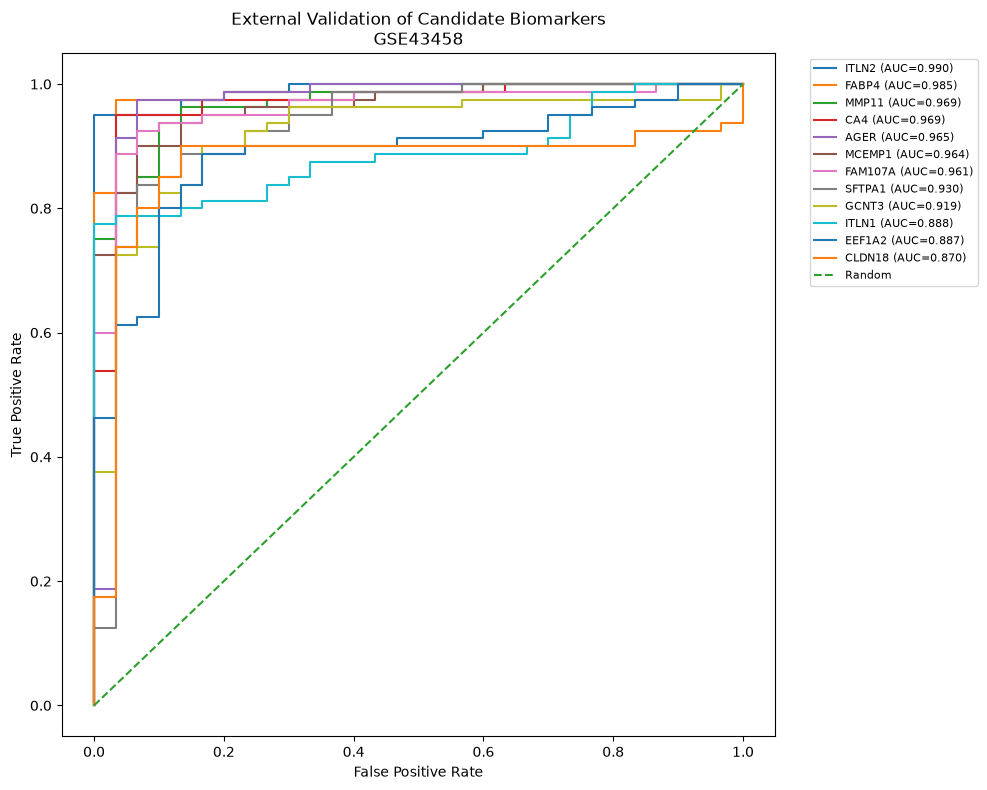


BEST EXTERNALLY VALIDATED BIOMARKER
Gene: ITLN2
Validation AUC: 0.990

Building multi-gene biomarker panel...

External validation panel AUC: 0.997


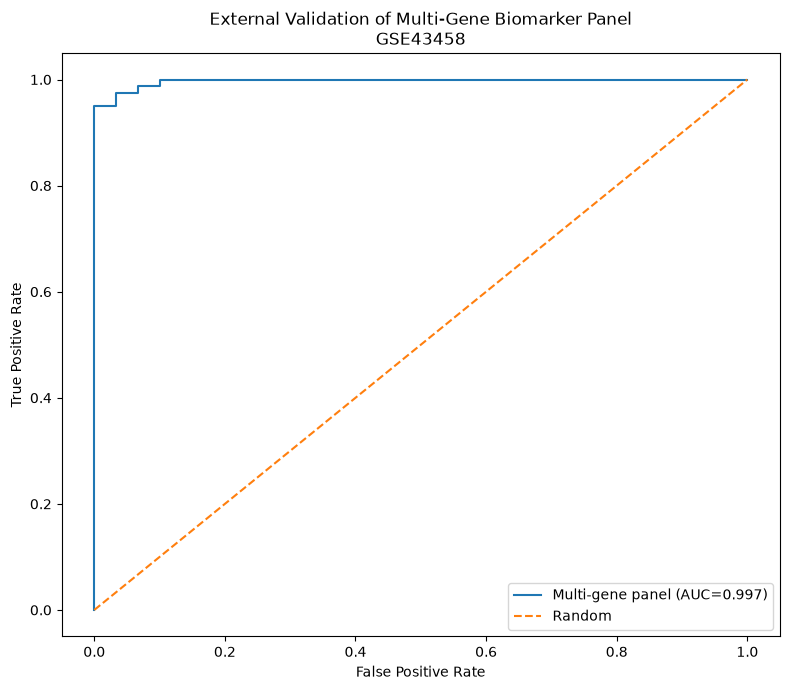


VALIDATION SUMMARY
                       metric     value
            Locked candidates        15
Candidates mapped to GSE43458        12
           Validation samples       110
            Validation tumors        80
           Validation normals        30
               Best biomarker     ITLN2
           Best biomarker AUC  0.990417
         Multi-gene panel AUC  0.997083

✓ ROC table saved.
✓ ROC figure saved.
✓ Panel ROC saved.
✓ Validation summary saved.

STEP 4 COMPLETE


In [102]:
# ============================================================
# FINAL FIX — REBUILD GSE43458 VALIDATION MATRIX
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, roc_auc_score

print("=" * 70)
print("GSE43458 — FINAL VALIDATION SETUP")
print("=" * 70)


# ============================================================
# 1. REBUILD VALIDATION METADATA WITH GSM IDs
# ============================================================

meta_val = metadata_43458.copy()

print("\nOriginal metadata columns:")
print(meta_val.columns.tolist())


# Find sample ID column
sample_id_candidates = [
    c for c in meta_val.columns
    if "sample" in c.lower()
    or c.lower() in ["gsm", "id"]
]

print("\nPossible sample-ID columns:")
print(sample_id_candidates)


if "sample_id" in meta_val.columns:

    sample_col = "sample_id"

elif len(sample_id_candidates) > 0:

    sample_col = sample_id_candidates[0]

else:

    raise ValueError(
        "Could not find sample ID column in metadata_43458."
    )


# Clean sample IDs
meta_val[sample_col] = (
    meta_val[sample_col]
    .astype(str)
    .str.strip()
    .str.strip('"')
)


# Set GSM IDs as index
meta_val = meta_val.set_index(
    sample_col
)


print(
    "\nMetadata now indexed by:",
    sample_col
)

print(
    "First 5 metadata IDs:"
)

print(
    meta_val.index[:5].tolist()
)


# ============================================================
# 2. CLEAN EXPRESSION SAMPLE IDs
# ============================================================

X_val_probe = expression_43458.copy()

X_val_probe.index = (
    X_val_probe.index
    .astype(str)
    .str.strip()
    .str.strip('"')
)

X_val_probe.columns = (
    X_val_probe.columns
    .astype(str)
    .str.strip()
    .str.strip('"')
)


print(
    "\nExpression samples:",
    len(X_val_probe.columns)
)

print(
    "Metadata samples:",
    len(meta_val.index)
)


# ============================================================
# 3. CHECK SAMPLE OVERLAP
# ============================================================

common_samples = [
    s
    for s in X_val_probe.columns
    if s in meta_val.index
]


print(
    "\nCommon samples:",
    len(common_samples)
)


if len(common_samples) != 110:

    print(
        "\nFirst expression IDs:"
    )

    print(
        list(X_val_probe.columns[:10])
    )

    print(
        "\nFirst metadata IDs:"
    )

    print(
        list(meta_val.index[:10])
    )

    raise ValueError(
        f"Expected 110 common samples, "
        f"found {len(common_samples)}."
    )


# Align
X_val_probe = X_val_probe.loc[
    :,
    common_samples
]

meta_val = meta_val.loc[
    common_samples
]


print(
    "✓ Sample alignment successful."
)


# ============================================================
# 4. REBUILD GPL6244 PROBE → GENE MAPPING
# ============================================================

print(
    "\nRebuilding GPL6244 gene mapping..."
)

annot = annotation_43458.copy()

annot["ID"] = (
    annot["ID"]
    .astype(str)
    .str.strip()
    .str.strip('"')
)


def extract_gene_symbol(value):

    if pd.isna(value):
        return np.nan

    text = str(value).strip()

    if text in [
        "",
        "---",
        "nan",
        "None"
    ]:
        return np.nan

    parts = [
        x.strip()
        for x in text.split(" // ")
    ]

    if len(parts) < 2:
        return np.nan

    symbol = parts[1].strip()

    if " /// " in symbol:
        symbol = (
            symbol
            .split(" /// ")[0]
            .strip()
        )

    if symbol in [
        "",
        "---",
        "NA",
        "N/A"
    ]:
        return np.nan

    return symbol.upper()


annot["gene_symbol"] = (
    annot["gene_assignment"]
    .apply(extract_gene_symbol)
)


mapping = (
    annot[
        [
            "ID",
            "gene_symbol"
        ]
    ]
    .dropna()
    .drop_duplicates()
)


print(
    "Mapped transcript clusters:",
    len(mapping)
)

print(
    "Unique genes:",
    mapping["gene_symbol"].nunique()
)


# ============================================================
# 5. BUILD GENE-LEVEL VALIDATION MATRIX
# ============================================================

print(
    "\nBuilding validation gene-expression matrix..."
)

val_long = X_val_probe.copy()

val_long.index.name = "ID"

val_long = (
    val_long
    .reset_index()
    .merge(
        mapping,
        on="ID",
        how="inner"
    )
)


X_val_gene = (
    val_long
    .drop(columns=["ID"])
    .groupby("gene_symbol")
    .median()
)


print(
    "Validation gene matrix:",
    X_val_gene.shape
)


# ============================================================
# 6. CHECK LOCKED BIOMARKERS
# ============================================================

available_candidates = [
    gene
    for gene in candidate_genes
    if gene.upper()
    in X_val_gene.index
]

missing_candidates = [
    gene
    for gene in candidate_genes
    if gene.upper()
    not in X_val_gene.index
]


print(
    "\n" + "=" * 70
)

print(
    "BIOMARKER MAPPING"
)

print(
    "=" * 70
)

print(
    "Locked candidates:",
    len(candidate_genes)
)

print(
    "Mapped candidates:",
    len(available_candidates)
)

print(
    "Missing candidates:",
    len(missing_candidates)
)

print(
    "\nMapped:"
)

print(
    available_candidates
)

if missing_candidates:

    print(
        "\nMissing:"
    )

    print(
        missing_candidates
    )


if len(available_candidates) < 5:

    raise ValueError(
        "Fewer than 5 candidates mapped."
    )


# ============================================================
# 7. VALIDATION LABELS
# ============================================================

if "status" not in meta_val.columns:

    raise ValueError(
        "status column missing."
    )


y_val = (
    meta_val["status"]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
)


if y_val.isna().any():

    print(
        meta_val["status"].value_counts()
    )

    raise ValueError(
        "Unknown tumor/normal labels."
    )


y_val = y_val.astype(int)


print(
    "\nValidation classes:"
)

print(
    meta_val["status"].value_counts()
)


# ============================================================
# 8. INDIVIDUAL BIOMARKER ROC/AUC
# ============================================================

print(
    "\nCalculating external validation AUC..."
)

roc_results = []

roc_curves = {}


for gene in available_candidates:

    discovery_log2fc = (
        candidate_results
        .loc[gene, "log2FC"]
    )

    direction = np.sign(
        discovery_log2fc
    )

    score = (
        X_val_gene.loc[gene]
        * direction
    )

    auc_value = roc_auc_score(
        y_val,
        score
    )

    fpr, tpr, thresholds = roc_curve(
        y_val,
        score
    )

    roc_curves[gene] = (
        fpr,
        tpr
    )

    roc_results.append({

        "gene":
            gene,

        "discovery_log2FC":
            discovery_log2fc,

        "discovery_FDR":
            candidate_results
            .loc[gene, "FDR"],

        "consistency":
            candidate_results
            .loc[gene, "consistency"],

        "validation_AUC":
            auc_value,

        "direction":
            "Up"
            if direction > 0
            else "Down"
    })


roc_results = (
    pd.DataFrame(roc_results)
    .sort_values(
        "validation_AUC",
        ascending=False
    )
)


print(
    "\n" + "=" * 70
)

print(
    "EXTERNAL VALIDATION RESULTS"
)

print(
    "=" * 70
)

print(
    roc_results.to_string(
        index=False
    )
)


# ============================================================
# 9. SAVE AUC TABLE
# ============================================================

roc_results.to_csv(
    "../results/tables/"
    "external_validation_gene_auc.csv",
    index=False
)


# ============================================================
# 10. ROC FIGURE
# ============================================================

plt.figure(
    figsize=(10, 8)
)


for gene in roc_results["gene"]:

    fpr, tpr = (
        roc_curves[gene]
    )

    auc_value = (
        roc_results
        .loc[
            roc_results["gene"] == gene,
            "validation_AUC"
        ]
        .iloc[0]
    )

    plt.plot(
        fpr,
        tpr,
        label=(
            f"{gene} "
            f"(AUC={auc_value:.3f})"
        )
    )


plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "External Validation of Candidate Biomarkers\n"
    "GSE43458"
)

plt.legend(
    bbox_to_anchor=(1.04, 1),
    loc="upper left",
    fontsize=8
)

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "external_validation_ROC_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. BEST BIOMARKER
# ============================================================

best_gene = (
    roc_results.iloc[0]["gene"]
)

best_auc = (
    roc_results.iloc[0]["validation_AUC"]
)


print(
    "\n" + "=" * 70
)

print(
    "BEST EXTERNALLY VALIDATED BIOMARKER"
)

print(
    "=" * 70
)

print(
    f"Gene: {best_gene}"
)

print(
    f"Validation AUC: {best_auc:.3f}"
)


# ============================================================
# 12. DIRECTION-AWARE MULTI-GENE PANEL
# ============================================================

print(
    "\nBuilding multi-gene biomarker panel..."
)

panel_genes = (
    available_candidates.copy()
)


# Validation expression
X_panel_val = (
    X_val_gene
    .loc[panel_genes]
    .T
)


# Dataset-wise label-free z-score
X_panel_val_z = (
    X_panel_val
    -
    X_panel_val.mean(axis=0)
) / (
    X_panel_val.std(
        axis=0,
        ddof=0
    )
)


# Direction from discovery
directions = pd.Series({

    gene:
        np.sign(
            candidate_results
            .loc[gene, "log2FC"]
        )

    for gene in panel_genes

})


# Direction-aware panel score
validation_panel_score = (
    X_panel_val_z
    .multiply(
        directions,
        axis=1
    )
    .mean(axis=1)
)


external_panel_auc = (
    roc_auc_score(
        y_val,
        validation_panel_score
    )
)


print(
    "\nExternal validation panel AUC:",
    f"{external_panel_auc:.3f}"
)


# ============================================================
# 13. PANEL ROC
# ============================================================

fpr_panel, tpr_panel, _ = (
    roc_curve(
        y_val,
        validation_panel_score
    )
)


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    fpr_panel,
    tpr_panel,
    label=(
        f"Multi-gene panel "
        f"(AUC={external_panel_auc:.3f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "External Validation of Multi-Gene Biomarker Panel\n"
    "GSE43458"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "external_validation_panel_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 14. SAVE FINAL SUMMARY
# ============================================================

validation_summary = pd.DataFrame({

    "metric": [

        "Locked candidates",

        "Candidates mapped to GSE43458",

        "Validation samples",

        "Validation tumors",

        "Validation normals",

        "Best biomarker",

        "Best biomarker AUC",

        "Multi-gene panel AUC"

    ],

    "value": [

        len(candidate_genes),

        len(available_candidates),

        len(y_val),

        int(
            (y_val == 1).sum()
        ),

        int(
            (y_val == 0).sum()
        ),

        best_gene,

        best_auc,

        external_panel_auc

    ]

})


validation_summary.to_csv(
    "../results/tables/"
    "validation_summary.csv",
    index=False
)


print(
    "\n" + "=" * 70
)

print(
    "VALIDATION SUMMARY"
)

print(
    "=" * 70
)

print(
    validation_summary.to_string(
        index=False
    )
)


print(
    "\n✓ ROC table saved."
)

print(
    "✓ ROC figure saved."
)

print(
    "✓ Panel ROC saved."
)

print(
    "✓ Validation summary saved."
)

print(
    "\n" + "=" * 70
)

print(
    "STEP 4 COMPLETE"
)

print(
    "=" * 70
)

STEP 5 — LEAKAGE-SAFE MACHINE LEARNING

Preparing discovery cohort...
Genes used: 12
['CLDN18', 'FABP4', 'ITLN2', 'AGER', 'SFTPA1', 'CA4', 'FAM107A', 'MMP11', 'ITLN1', 'MCEMP1', 'EEF1A2', 'GCNT3']

ML matrix: (166, 12)
Tumor samples: 83
Normal samples: 83
Patient groups: 83

Checking patient-level grouping...
Pairs with exactly 2 samples: 83
✓ Every patient contributes exactly one Tumor and one Normal sample.

Cross-validation: 5-fold GroupKFold
Important: matched tumor/normal pairs remain in the same fold.

Generating out-of-fold predictions...

5-FOLD GROUP-AWARE ML PERFORMANCE
ROC-AUC:      0.9999
Accuracy:     0.9940
Sensitivity:  0.9880
Specificity:  1.0000

Confusion matrix:
[[83  0]
 [ 1 82]]

Classification report:
              precision    recall  f1-score   support

      Normal       0.99      1.00      0.99        83
       Tumor       1.00      0.99      0.99        83

    accuracy                           0.99       166
   macro avg       0.99      0.99      0.99      

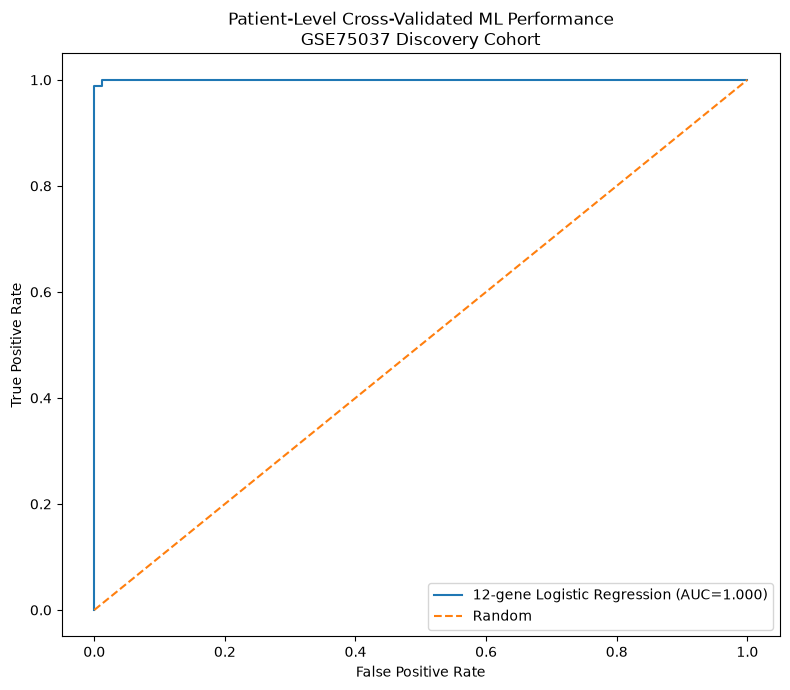

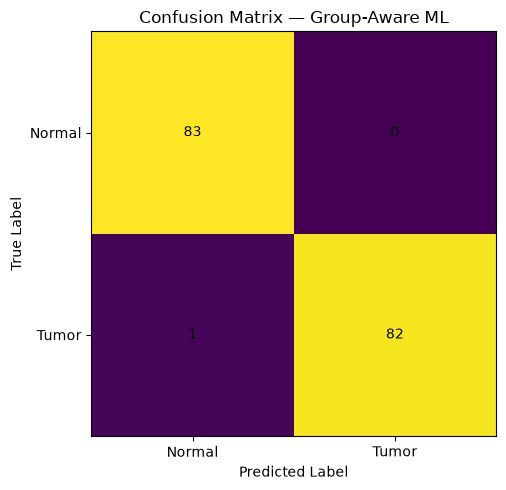


SINGLE-BIOMARKER BASELINE
ITLN2 group-aware AUC: 0.9926

✓ ML performance table saved.
✓ Out-of-fold predictions saved.
✓ ML ROC figure saved.
✓ Confusion matrix saved.

STEP 5 COMPLETE


In [103]:
# ============================================================
# STEP 5 — LEAKAGE-SAFE MACHINE LEARNING VALIDATION
# GSE75037 discovery cohort
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("=" * 70)
print("STEP 5 — LEAKAGE-SAFE MACHINE LEARNING")
print("=" * 70)


# ============================================================
# 1. PREPARE DISCOVERY DATA
# ============================================================

print("\nPreparing discovery cohort...")

# Use only the 12 genes that successfully mapped
# to the external validation cohort.
ml_genes = available_candidates.copy()

print(
    "Genes used:",
    len(ml_genes)
)

print(
    ml_genes
)


# Samples × genes
X_ml = (
    X_disc
    .loc[ml_genes]
    .T
)


# Tumor = 1, Normal = 0
y_ml = (
    meta_disc
    .loc[X_ml.index, "status_clean"]
    .map({
        "Tumor": 1,
        "Normal": 0
    })
    .astype(int)
)


# Patient pair = grouping variable
groups_ml = (
    meta_disc
    .loc[X_ml.index, "pair_id"]
)


print(
    "\nML matrix:",
    X_ml.shape
)

print(
    "Tumor samples:",
    (y_ml == 1).sum()
)

print(
    "Normal samples:",
    (y_ml == 0).sum()
)

print(
    "Patient groups:",
    groups_ml.nunique()
)


# ============================================================
# 2. VERIFY NO PATIENT HAS BEEN SPLIT
# ============================================================

print(
    "\nChecking patient-level grouping..."
)

pair_counts = (
    groups_ml
    .value_counts()
)

print(
    "Pairs with exactly 2 samples:",
    (pair_counts == 2).sum()
)

if not (pair_counts == 2).all():

    raise ValueError(
        "Some patient pairs do not contain exactly 2 samples."
    )

print(
    "✓ Every patient contributes exactly one Tumor "
    "and one Normal sample."
)


# ============================================================
# 3. DEFINE GROUP-AWARE CROSS-VALIDATION
# ============================================================

cv = GroupKFold(
    n_splits=5
)

print(
    "\nCross-validation:",
    "5-fold GroupKFold"
)

print(
    "Important: matched tumor/normal pairs "
    "remain in the same fold."
)


# ============================================================
# 4. LOGISTIC REGRESSION PIPELINE
# ============================================================

model = Pipeline([
    
    (
        "scaler",
        StandardScaler()
    ),

    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            random_state=42
        )
    )
])


# ============================================================
# 5. OUT-OF-FOLD PREDICTIONS
# ============================================================

print(
    "\nGenerating out-of-fold predictions..."
)

oof_probability = cross_val_predict(
    model,
    X_ml,
    y_ml,
    cv=cv,
    groups=groups_ml,
    method="predict_proba"
)[:, 1]


oof_prediction = (
    oof_probability >= 0.5
).astype(int)


# ============================================================
# 6. PERFORMANCE METRICS
# ============================================================

ml_auc = roc_auc_score(
    y_ml,
    oof_probability
)

ml_accuracy = accuracy_score(
    y_ml,
    oof_prediction
)

cm = confusion_matrix(
    y_ml,
    oof_prediction
)

tn, fp, fn, tp = cm.ravel()

ml_sensitivity = (
    tp / (tp + fn)
    if (tp + fn) > 0
    else np.nan
)

ml_specificity = (
    tn / (tn + fp)
    if (tn + fp) > 0
    else np.nan
)


print(
    "\n" + "=" * 70
)

print(
    "5-FOLD GROUP-AWARE ML PERFORMANCE"
)

print(
    "=" * 70
)

print(
    f"ROC-AUC:      {ml_auc:.4f}"
)

print(
    f"Accuracy:     {ml_accuracy:.4f}"
)

print(
    f"Sensitivity:  {ml_sensitivity:.4f}"
)

print(
    f"Specificity:  {ml_specificity:.4f}"
)

print(
    "\nConfusion matrix:"
)

print(
    cm
)


# ============================================================
# 7. CLASSIFICATION REPORT
# ============================================================

print(
    "\nClassification report:"
)

print(
    classification_report(
        y_ml,
        oof_prediction,
        target_names=[
            "Normal",
            "Tumor"
        ]
    )
)


# ============================================================
# 8. ROC CURVE
# ============================================================

fpr_ml, tpr_ml, _ = roc_curve(
    y_ml,
    oof_probability
)


plt.figure(
    figsize=(8, 7)
)

plt.plot(
    fpr_ml,
    tpr_ml,
    label=f"12-gene Logistic Regression "
          f"(AUC={ml_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random"
)

plt.xlabel(
    "False Positive Rate"
)

plt.ylabel(
    "True Positive Rate"
)

plt.title(
    "Patient-Level Cross-Validated ML Performance\n"
    "GSE75037 Discovery Cohort"
)

plt.legend()

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "ML_group_aware_ROC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 9. CONFUSION MATRIX FIGURE
# ============================================================

plt.figure(
    figsize=(6, 5)
)

plt.imshow(
    cm,
    interpolation="nearest"
)

plt.title(
    "Confusion Matrix — Group-Aware ML"
)

plt.xlabel(
    "Predicted Label"
)

plt.ylabel(
    "True Label"
)

plt.xticks(
    [0, 1],
    ["Normal", "Tumor"]
)

plt.yticks(
    [0, 1],
    ["Normal", "Tumor"]
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "ML_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 10. SINGLE-BIOMARKER BASELINE — ITLN2
# ============================================================

best_gene = "ITLN2"

print(
    "\n" + "=" * 70
)

print(
    "SINGLE-BIOMARKER BASELINE"
)

print(
    "=" * 70
)

if best_gene in X_ml.columns:

    X_single = X_ml[
        [best_gene]
    ]

    single_model = Pipeline([

        (
            "scaler",
            StandardScaler()
        ),

        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                random_state=42
            )
        )
    ])

    single_oof_probability = (
        cross_val_predict(
            single_model,
            X_single,
            y_ml,
            cv=cv,
            groups=groups_ml,
            method="predict_proba"
        )[:, 1]
    )

    single_auc = roc_auc_score(
        y_ml,
        single_oof_probability
    )

    print(
        f"{best_gene} group-aware AUC: "
        f"{single_auc:.4f}"
    )

else:

    single_auc = np.nan

    print(
        f"{best_gene} not available in ML matrix."
    )


# ============================================================
# 11. SAVE ML RESULTS
# ============================================================

ml_results = pd.DataFrame({

    "model": [
        "ITLN2 single biomarker",
        "12-gene logistic regression panel"
    ],

    "ROC_AUC": [
        single_auc,
        ml_auc
    ],

    "accuracy": [
        np.nan,
        ml_accuracy
    ],

    "sensitivity": [
        np.nan,
        ml_sensitivity
    ],

    "specificity": [
        np.nan,
        ml_specificity
    ]

})


ml_results.to_csv(
    "../results/tables/"
    "ML_group_aware_performance.csv",
    index=False
)


# Save out-of-fold predictions
oof_results = pd.DataFrame({

    "sample_id":
        X_ml.index,

    "pair_id":
        groups_ml.values,

    "true_label":
        y_ml.values,

    "predicted_probability":
        oof_probability,

    "predicted_label":
        oof_prediction

})


oof_results.to_csv(
    "../results/tables/"
    "ML_out_of_fold_predictions.csv",
    index=False
)


# ============================================================
# 12. FINAL MESSAGE
# ============================================================

print(
    "\n✓ ML performance table saved."
)

print(
    "✓ Out-of-fold predictions saved."
)

print(
    "✓ ML ROC figure saved."
)

print(
    "✓ Confusion matrix saved."
)

print(
    "\n" + "=" * 70
)

print(
    "STEP 5 COMPLETE"
)

print(
    "=" * 70
)

In [104]:
# ============================================================
# STEP 6 — FINAL BIOMARKER RANKING TABLE
# ============================================================

print("=" * 70)
print("STEP 6 — FINAL BIOMARKER SUMMARY")
print("=" * 70)

final_biomarker_table = (
    roc_results[
        [
            "gene",
            "discovery_log2FC",
            "discovery_FDR",
            "consistency",
            "validation_AUC",
            "direction"
        ]
    ]
    .copy()
)

# Rank by external validation AUC
final_biomarker_table = (
    final_biomarker_table
    .sort_values(
        "validation_AUC",
        ascending=False
    )
    .reset_index(drop=True)
)

final_biomarker_table.insert(
    0,
    "validation_rank",
    range(
        1,
        len(final_biomarker_table) + 1
    )
)

print(
    "\nFINAL VALIDATED BIOMARKER PANEL"
)

print(
    final_biomarker_table.to_string(
        index=False
    )
)


# Save
final_biomarker_table.to_csv(
    "../results/tables/"
    "final_validated_biomarker_panel.csv",
    index=False
)

print(
    "\n✓ Final biomarker table saved."
)

print(
    "\nTop 5 externally validated biomarkers:"
)

print(
    final_biomarker_table[
        [
            "validation_rank",
            "gene",
            "validation_AUC",
            "direction"
        ]
    ]
    .head(5)
    .to_string(index=False)
)

print(
    "\nSTEP 6 COMPLETE."
)

STEP 6 — FINAL BIOMARKER SUMMARY

FINAL VALIDATED BIOMARKER PANEL
 validation_rank    gene  discovery_log2FC  discovery_FDR  consistency  validation_AUC direction
               1   ITLN2         -6.018506   3.396013e-47     1.000000        0.990417      Down
               2   FABP4         -6.025675   7.461619e-57     1.000000        0.985000      Down
               3   MMP11          5.120181   7.815709e-34     0.987952        0.969167        Up
               4     CA4         -5.490265   5.628515e-42     1.000000        0.969167      Down
               5    AGER         -5.715253   6.053710e-43     1.000000        0.965000      Down
               6  MCEMP1         -5.051819   6.501956e-38     1.000000        0.963750      Down
               7 FAM107A         -5.176530   1.597704e-46     0.987952        0.961250      Down
               8  SFTPA1         -5.535241   3.435712e-25     0.963855        0.929583      Down
               9   GCNT3          4.924301   1.819665e-29    

STEP 7 — FINAL BIOMARKER FIGURES


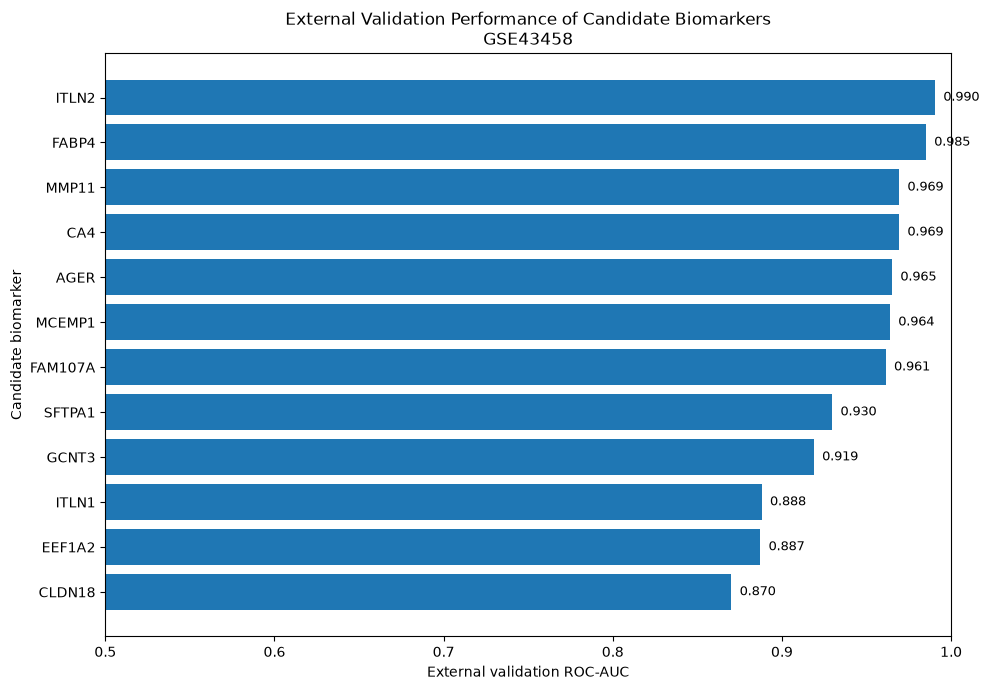

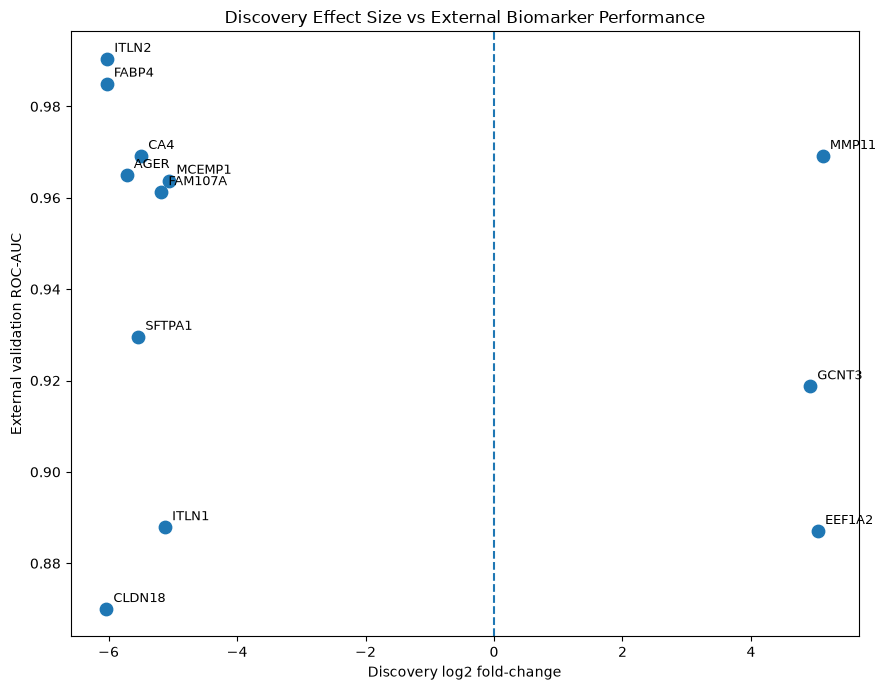


✓ Final AUC comparison figure saved.
✓ Effect-size vs AUC figure saved.

STEP 7 COMPLETE.


In [105]:
# ============================================================
# STEP 7 — FINAL BIOMARKER VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

print("=" * 70)
print("STEP 7 — FINAL BIOMARKER FIGURES")
print("=" * 70)

# ------------------------------------------------------------
# 1. Validation AUC bar plot
# ------------------------------------------------------------

plot_data = (
    final_biomarker_table
    .sort_values("validation_AUC", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data["gene"],
    plot_data["validation_AUC"]
)

plt.xlabel("External validation ROC-AUC")
plt.ylabel("Candidate biomarker")
plt.title(
    "External Validation Performance of Candidate Biomarkers\n"
    "GSE43458"
)

plt.xlim(0.5, 1.0)

for i, value in enumerate(
    plot_data["validation_AUC"]
):
    plt.text(
        value + 0.005,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "final_biomarker_AUC_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 2. Discovery effect size vs external validation
# ------------------------------------------------------------

plt.figure(figsize=(9, 7))

plt.scatter(
    final_biomarker_table["discovery_log2FC"],
    final_biomarker_table["validation_AUC"],
    s=80
)

for _, row in final_biomarker_table.iterrows():

    plt.annotate(
        row["gene"],
        (
            row["discovery_log2FC"],
            row["validation_AUC"]
        ),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Discovery log2 fold-change"
)

plt.ylabel(
    "External validation ROC-AUC"
)

plt.title(
    "Discovery Effect Size vs External Biomarker Performance"
)

plt.tight_layout()

plt.savefig(
    "../results/figures/"
    "discovery_effect_vs_validation_AUC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("\n✓ Final AUC comparison figure saved.")
print("✓ Effect-size vs AUC figure saved.")

print("\nSTEP 7 COMPLETE.")